Starting Variational EM optimization...
EM Iteration 50/300, ELBO: -89.5932
EM Iteration 100/300, ELBO: -67.4517
EM Iteration 150/300, ELBO: -51.5538
EM Iteration 200/300, ELBO: -41.8463
EM Iteration 250/300, ELBO: -36.0874
EM Iteration 300/300, ELBO: -32.8495

Optimization finished.

--- Initial Z ---
[-5.         -4.47368421 -3.94736842 -3.42105263 -2.89473684 -2.36842105
 -1.84210526 -1.31578947 -0.78947368 -0.26315789  0.26315789  0.78947368
  1.31578947  1.84210526  2.36842105  2.89473684  3.42105263  3.94736842
  4.47368421  5.        ]

--- Optimized Z ---
[-4.93490661 -4.61668767 -3.65617316 -3.83372345 -2.87937094 -2.119281
 -1.46039113 -2.0990684  -1.04497729  0.14810658 -0.05281121  0.52343339
  1.33342164  1.83174988  3.00253216  2.30393539  3.19205054  4.1035617
  4.49773357  4.94179868]
-------------------


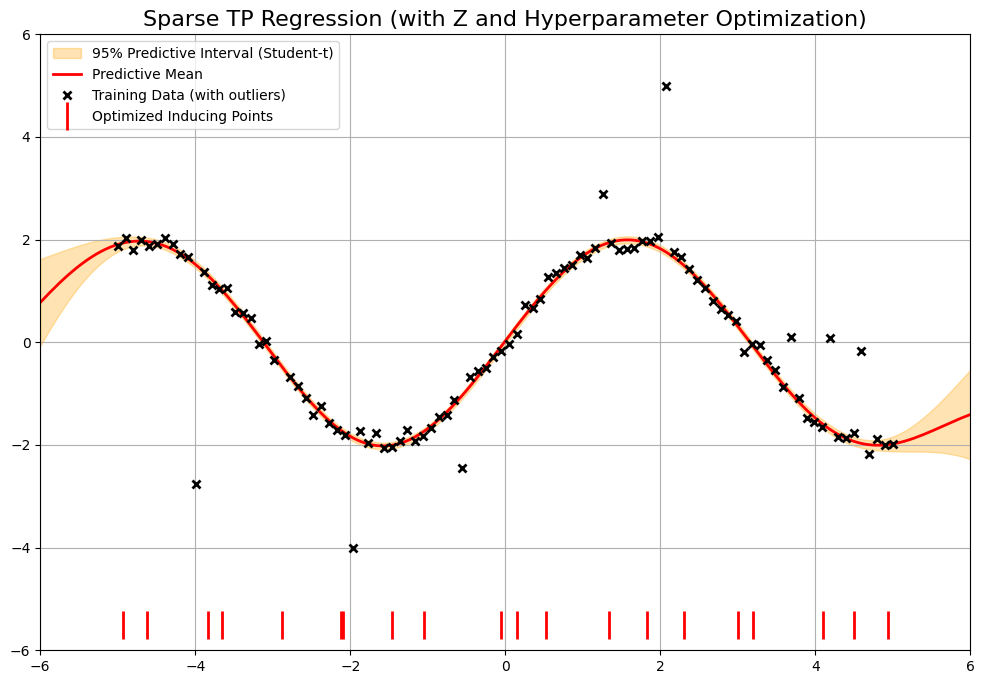

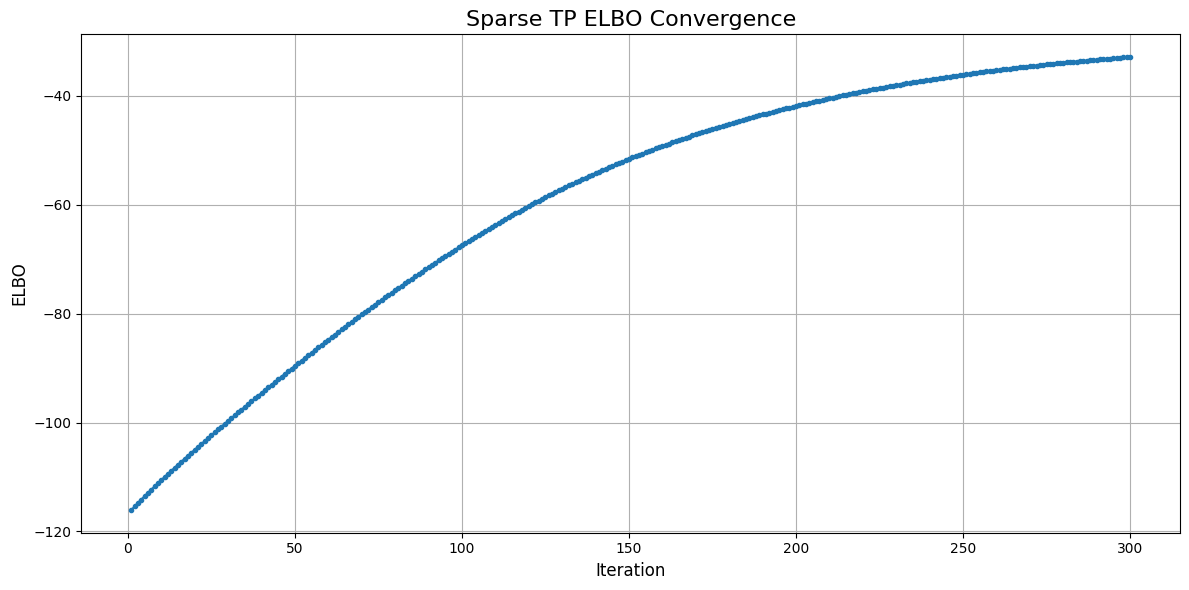

In [4]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.stats import t
import math

def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    # Ensure lengthscale and variance are tensors for autograd
    lengthscale = torch.as_tensor(lengthscale, dtype=X1.dtype, device=X1.device)
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    
    sqdist = torch.cdist(X1, X2, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / lengthscale**2)

class TPRegression:
    """
    Implementation of Variational EM for Student-t Process Regression.
    - E-Step: CAVI updates for variational parameters.
    - M-Step: Gradient-based optimization of model hyperparameters and inducing points.
    """
    def __init__(self, X, y, Z_initial, nu_f=5.0, nu_e=5.0, kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=1.0):
        self.X = X
        self.y = y.squeeze()
        self.N, self.D = X.shape
        self.M = Z_initial.shape[0]

        # --- Initialize Hyperparameters and Inducing Points (M-step) ---
        # These are now learnable parameters. We optimize their log for stability.
        self.log_nu_f = torch.nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_epsilon = torch.nn.Parameter(torch.log(torch.tensor(nu_e)))
        self.log_sigma_sq = torch.nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_kernel_lengthscale = torch.nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = torch.nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.Z = torch.nn.Parameter(Z_initial.clone())

        # --- Initialize Variational Parameters (E-step) ---
        self.m_u = torch.zeros(self.M, 1)
        self.S_u = torch.eye(self.M)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)
        self.alpha_lambda = torch.ones(self.N)
        self.beta_lambda = torch.ones(self.N)
        
    def _get_hyperparams(self):
        """Returns the exponentiated (positive) hyperparameters."""
        return {
            "nu_f": torch.exp(self.log_nu_f),
            "nu_epsilon": torch.exp(self.log_nu_epsilon),
            "sigma_sq": torch.exp(self.log_sigma_sq),
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance)
        }
        
    def _e_step_deprecated(self, cavi_max_iter=1):
        """Performs the CAVI updates for the variational parameters (E-Step)."""
        with torch.no_grad(): # No gradients needed for the E-step updates
            params = self._get_hyperparams()
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M) * 1e-6
            K_ZZ_inv = torch.inverse(K_ZZ)
            K_XZ = rbf_kernel(self.X, self.Z, params['lengthscale'], params['variance'])
            
            for _ in range(cavi_max_iter):
                # Update q(lambda)
                K_ZZ_inv_m_u = torch.linalg.solve(K_ZZ, self.m_u)
                expected_f_mean = K_XZ @ K_ZZ_inv_m_u
                if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
                else: expected_r_inv = self.beta_r
                k_ii = torch.diag(rbf_kernel(self.X, self.X, params['lengthscale'], params['variance']))
                K_XZ_K_ZZ_inv = K_XZ @ K_ZZ_inv
                var_f_term1 = expected_r_inv * (k_ii - (K_XZ_K_ZZ_inv * K_XZ).sum(dim=1))
                var_f_term2 = (K_XZ_K_ZZ_inv @ self.S_u * K_XZ_K_ZZ_inv).sum(dim=1)
                var_f = var_f_term1 + var_f_term2
                expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f
                self.alpha_lambda = params['nu_epsilon'] / 2.0 + 0.5
                self.beta_lambda = params['nu_epsilon'] / 2.0 + (0.5 / params['sigma_sq']) * expected_sq_error

                # Update q(r)
                trace_term = torch.trace(K_ZZ_inv @ self.S_u)
                mean_term = self.m_u.T @ K_ZZ_inv @ self.m_u
                expected_u_quadratic_form = trace_term + mean_term
                self.alpha_r = params['nu_f'] / 2.0 + self.M / 2.0
                self.beta_r = params['nu_f'] / 2.0 + 0.5 * expected_u_quadratic_form.squeeze()

                # Update q(u)
                expected_r = self.alpha_r / self.beta_r
                expected_lambda = self.alpha_lambda / self.beta_lambda
                precision_u_prior = expected_r * K_ZZ_inv
                K_ZX = K_XZ.T
                A = K_ZX * (expected_lambda / params['sigma_sq'])
                B = A @ K_XZ
                precision_u_lik = K_ZZ_inv.T @ B @ K_ZZ_inv
                precision_u = precision_u_prior + precision_u_lik
                self.S_u = torch.inverse(precision_u + torch.eye(self.M) * 1e-6)
                b = K_ZZ_inv.T @ (K_ZX @ (expected_lambda * self.y / params['sigma_sq']))
                self.m_u = (self.S_u @ b).unsqueeze(1)

    def _e_step(self, cavi_max_iter=1):
        """
        CAVIアップデートを効率的かつ数値的に安定した方法で実行します (E-Step)。
        逆行列の直接計算を避け、コレスキー分解と線形ソルバーを活用します。
        """
        with torch.no_grad(): # E-stepの更新では勾配は不要
            params = self._get_hyperparams()
            
            # --- ループ前の事前計算 ---
            # K_ZZは対称正定値なので、コレスキー分解が最適です。
            # K_ZZ = L_ZZ @ L_ZZ.T となる下三角行列 L_ZZ を計算します。
            # この L_ZZ を使って、K_ZZ_inv を介した計算を効率化します。
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
            L_ZZ = torch.linalg.cholesky(K_ZZ)
            
            K_XZ = rbf_kernel(self.X, self.Z, params['lengthscale'], params['variance'])
            K_ZX = K_XZ.T

            # k_ii は X の対角要素であり、RBFカーネルでは常に variance になります。
            # Nが大きい場合、(N,N)行列を作らずに済むため効率的です。
            k_ii = torch.full((self.X.shape[0],), params['variance'], device=self.X.device)

            for _ in range(cavi_max_iter):
                # --- q(lambda) の更新 ---
                # K_ZZ @ x = m_u を解くことで K_ZZ_inv @ m_u を計算
                KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
                expected_f_mean = K_XZ @ KZZ_inv_m_u

                if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
                else: expected_r_inv = self.beta_r
                
                # K_XZ @ K_ZZ_inv を効率的に計算します。
                # X = K_XZ @ K_ZZ_inv <=> X.T = K_ZZ_inv @ K_ZX
                # L_ZZ @ L_ZZ.T @ X.T = K_ZX を解きます。
                KXZ_KZZ_inv = torch.cholesky_solve(K_ZX, L_ZZ).T

                # var(f) の計算
                # diag(A @ B) = (A * B.T).sum(dim=1) を利用
                var_f_term1 = expected_r_inv * (k_ii - (KXZ_KZZ_inv * K_XZ).sum(dim=1))
                # diag(KXZ_KZZ_inv @ S_u @ KXZ_KZZ_inv.T) と等価
                var_f_term2 = (KXZ_KZZ_inv @ self.S_u * KXZ_KZZ_inv).sum(dim=1)
                var_f = var_f_term1 + var_f_term2

                expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f
                self.alpha_lambda = params['nu_epsilon'] / 2.0 + 0.5
                self.beta_lambda = params['nu_epsilon'] / 2.0 + (0.5 / params['sigma_sq']) * expected_sq_error

                # --- q(r) の更新 ---
                # E[u.T @ K_ZZ_inv @ u] = trace(K_ZZ_inv @ S_u) + m_u.T @ K_ZZ_inv @ m_u
                # cholesky_solve と計算済みの中間変数を再利用します。
                trace_term = torch.trace(torch.cholesky_solve(self.S_u, L_ZZ))
                mean_term = self.m_u.T @ KZZ_inv_m_u # 上で計算した値を再利用
                expected_u_quadratic_form = trace_term + mean_term
                
                self.alpha_r = params['nu_f'] / 2.0 + self.M / 2.0
                self.beta_r = params['nu_f'] / 2.0 + 0.5 * expected_u_quadratic_form.squeeze()

                # --- q(u) の更新 ---
                # S_u と m_u の更新式を、逆行列を使わない形に変形して計算します。
                # S_u = K_ZZ @ (E[r]*K_ZZ + B)^-1 @ K_ZZ
                # m_u = S_u @ K_ZZ_inv @ b_lik = K_ZZ @ (E[r]*K_ZZ + B)^-1 @ b_lik
                # ここで B = K_ZX @ diag(c) @ K_XZ, b_lik = K_ZX @ (c*y)
                expected_r = self.alpha_r / self.beta_r
                expected_lambda = self.alpha_lambda / self.beta_lambda
                c = expected_lambda.squeeze() / params['sigma_sq']

                # B = K_ZX @ diag(c) @ K_XZ を効率的に計算
                B = (K_ZX * c) @ K_XZ
                
                # (E[r]*K_ZZ + B) を計算し、コレスキー分解
                precision_inner = expected_r * K_ZZ + B
                L_precision_inner = torch.linalg.cholesky(precision_inner)
                
                # S_u = K_ZZ @ precision_inner_inv @ K_ZZ
                # tmp = precision_inner_inv @ K_ZZ を線形ソルバーで解く
                tmp_S = torch.cholesky_solve(K_ZZ, L_precision_inner)
                self.S_u = K_ZZ @ tmp_S

                # m_u = K_ZZ @ precision_inner_inv @ (K_ZX @ (c*y))
                # y_term = K_ZX @ (c*y)
                y_term = K_ZX @ (self.y.squeeze() * c)
                # m_u_unscaled = precision_inner_inv @ y_term を線形ソルバーで解く
                m_u_unscaled = torch.cholesky_solve(y_term.unsqueeze(1), L_precision_inner)
                self.m_u = K_ZZ @ m_u_unscaled

    def _calculate_elbo(self):
        """Calculates the Evidence Lower Bound (ELBO) for the M-step."""
        params = self._get_hyperparams()
        
        K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M) * 1e-6
        K_ZZ_inv = torch.inverse(K_ZZ)
        K_XZ = rbf_kernel(self.X, self.Z, params['lengthscale'], params['variance'])
        k_ii = torch.diag(rbf_kernel(self.X, self.X, params['lengthscale'], params['variance']))

        # 1. Expected Log-Likelihood
        expected_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)
        expected_lambda = self.alpha_lambda / self.beta_lambda
        K_ZZ_inv_m_u = torch.linalg.solve(K_ZZ, self.m_u)
        expected_f_mean = K_XZ @ K_ZZ_inv_m_u
        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r
        K_XZ_K_ZZ_inv = K_XZ @ K_ZZ_inv
        var_f = expected_r_inv * (k_ii - (K_XZ_K_ZZ_inv * K_XZ).sum(dim=1)) + \
                (K_XZ_K_ZZ_inv @ self.S_u * K_XZ_K_ZZ_inv).sum(dim=1)
        expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f
        
        log_lik = 0.5 * torch.sum(expected_log_lambda - math.log(2 * math.pi) - torch.log(params['sigma_sq']) - \
                                  expected_lambda / params['sigma_sq'] * expected_sq_error)

        # 2. KL Divergences
        p_alpha_r, p_beta_r = params['nu_f'] / 2.0, params['nu_f'] / 2.0
        kl_r = (self.alpha_r - p_alpha_r) * torch.digamma(self.alpha_r) - torch.lgamma(self.alpha_r) + torch.lgamma(p_alpha_r) + \
               p_alpha_r * (torch.log(self.beta_r) - torch.log(p_beta_r)) + self.alpha_r * (p_beta_r - self.beta_r) / self.beta_r
        
        expected_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        kl_u = 0.5 * (
            -torch.logdet(self.S_u) - self.M * expected_log_r + torch.logdet(K_ZZ) + \
            (self.alpha_r / self.beta_r) * (torch.trace(K_ZZ_inv @ self.S_u) + self.m_u.T @ K_ZZ_inv @ self.m_u) - self.M
        ).squeeze()
        
        # CORRECTED a typo here: params['nu_e'] -> params['nu_epsilon']
        p_alpha_lambda, p_beta_lambda = params['nu_epsilon'] / 2.0, params['nu_epsilon'] / 2.0
        kl_lambda = torch.sum((self.alpha_lambda - p_alpha_lambda) * torch.digamma(self.alpha_lambda) - \
                    torch.lgamma(self.alpha_lambda) + torch.lgamma(p_alpha_lambda) + \
                    p_alpha_lambda * (torch.log(self.beta_lambda) - torch.log(p_beta_lambda)) + \
                    self.alpha_lambda * (p_beta_lambda - self.beta_lambda) / self.beta_lambda)

        return log_lik - kl_u - kl_r - kl_lambda

    def _m_step(self, optimizer):
        """Performs the gradient update for the hyperparameters (M-Step)."""
        optimizer.zero_grad()
        elbo = self._calculate_elbo()
        loss = -elbo # Maximize ELBO by minimizing -ELBO
        loss.backward()
        optimizer.step()
        return elbo.item()

    def fit(self, max_iter_global=100, cavi_max_iter=10, lr=0.01):
        """Runs the full Variational EM algorithm."""
        optimizer = optim.Adam(
            [self.log_nu_f, self.log_nu_epsilon, self.log_sigma_sq,
             self.log_kernel_lengthscale, self.log_kernel_variance, self.Z],
            lr=lr
        )
        
        elbo_history = []
        print("Starting Variational EM optimization...")
        for i in range(max_iter_global):
            self._e_step(cavi_max_iter=cavi_max_iter)
            elbo = self._m_step(optimizer)
            elbo_history.append(elbo)
            
            if (i + 1) % 50 == 0:
                print(f"EM Iteration {i+1}/{max_iter_global}, ELBO: {elbo:.4f}")
        
        print("\nOptimization finished.")
        return elbo_history

    def predict(self, X_test):
        """
        Makes predictions for new data X_test.
        Returns the parameters of the predictive Student-t distribution.
        """
        with torch.no_grad():
            params = self._get_hyperparams()
            
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M) * 1e-6
            K_ZZ_inv = torch.inverse(K_ZZ)
            K_star_Z = rbf_kernel(X_test, self.Z, params['lengthscale'], params['variance'])
            k_star_star = torch.diag(rbf_kernel(X_test, X_test, params['lengthscale'], params['variance']))

            K_ZZ_inv_m_u = torch.linalg.solve(K_ZZ, self.m_u)
            pred_mean = (K_star_Z @ K_ZZ_inv_m_u).squeeze()

            K_star_Z_K_ZZ_inv = K_star_Z @ K_ZZ_inv
            gp_var = k_star_star - (K_star_Z_K_ZZ_inv * K_star_Z).sum(dim=1) + \
                     (K_star_Z_K_ZZ_inv @ self.S_u * K_star_Z_K_ZZ_inv).sum(dim=1)
            
            pred_nu = 2 * self.alpha_r
            pred_scale_sq = gp_var * (self.beta_r / self.alpha_r)
            
            return pred_mean, pred_scale_sq, pred_nu

if __name__ == '__main__':

    torch.set_default_dtype(torch.float64)
    # 1. Generate data
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:10]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0

    # 2. Setup the model with INITIAL inducing points
    M = 20
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)

    model = TPRegression(
        X=X_train,
        y=y_train,
        Z_initial=Z_initial,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model and get ELBO history
    elbo_history = model.fit(max_iter_global=300, cavi_max_iter=5, lr=0.01)

    # Print final Z locations
    print("\n--- Initial Z ---")
    print(Z_initial.squeeze().numpy())
    print("\n--- Optimized Z ---")
    print(model.Z.detach().squeeze().numpy())
    print("-------------------")

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the regression results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, mew=2, label='Optimized Inducing Points')

    plt.title('Sparse TP Regression (with Z and Hyperparameter Optimization)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # 6. Visualize ELBO history
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(elbo_history) + 1), elbo_history, marker='.', linestyle='-')
    plt.title('Sparse TP ELBO Convergence', fontsize=16)
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('ELBO', fontsize=12)
    plt.grid(True)
    plt.tight_layout()

    plt.show()


Starting Variational EM optimization...
EM Iteration 50/300, ELBO: -85.7778
EM Iteration 100/300, ELBO: -63.4143
EM Iteration 150/300, ELBO: -46.4531
EM Iteration 200/300, ELBO: -34.9763
EM Iteration 250/300, ELBO: -27.5069
EM Iteration 300/300, ELBO: -22.8783

Optimization finished.

--- Initial Z ---
[-5.         -4.47368421 -3.94736842 -3.42105263 -2.89473684 -2.36842105
 -1.84210526 -1.31578947 -0.78947368 -0.26315789  0.26315789  0.78947368
  1.31578947  1.84210526  2.36842105  2.89473684  3.42105263  3.94736842
  4.47368421  5.        ]

--- Optimized Z ---
[-4.91824236 -4.51630606 -4.02217356 -3.51734171 -2.98924864 -2.48760712
 -1.93111845 -1.42455802 -0.87869664 -0.33201132  0.18334699  0.7335257
  1.26102805  1.79411772  2.35649689  2.95830383  3.53216625  4.07511302
  4.51152276  4.90497682]
-------------------


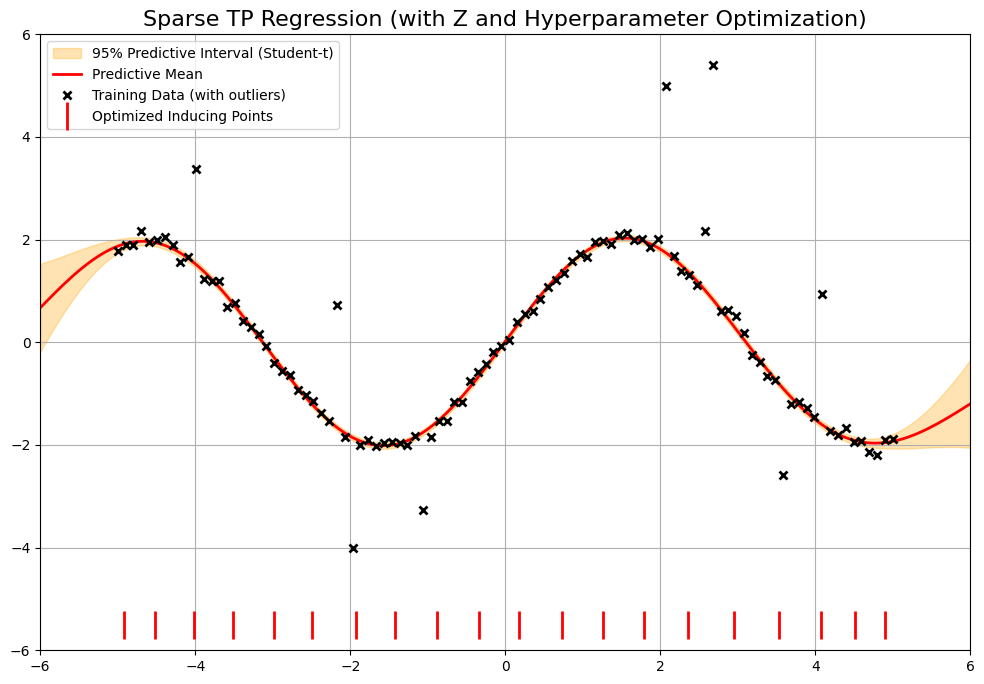

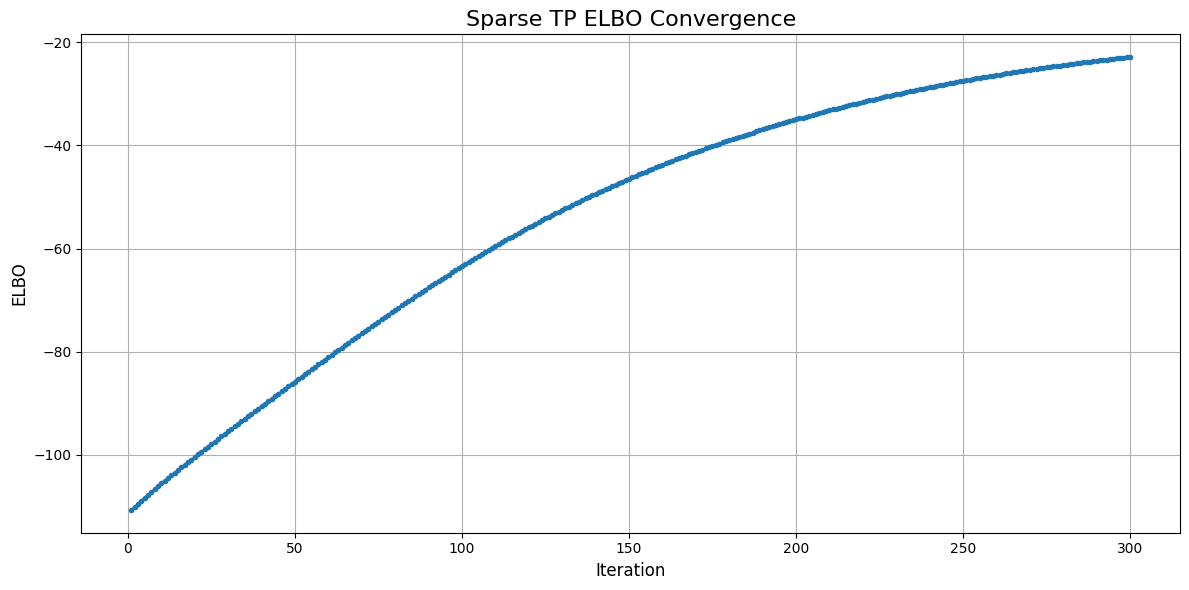

In [ ]:
import torch
import torch.optim as optim
import math

def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    # Ensure lengthscale and variance are tensors for autograd
    lengthscale = torch.as_tensor(lengthscale, dtype=X1.dtype, device=X1.device)
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    
    sqdist = torch.cdist(X1, X2, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / lengthscale**2)

class SparseTPRTFullBatch:
    """
    Implementation of Variational EM for Student-t Process Regression.
    - E-Step: CAVI updates for variational parameters.
    - M-Step: Gradient-based optimization of model hyperparameters and inducing points.
    """
    def __init__(self, X, y, Z_initial, nu_f=5.0, nu_e=5.0, kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=1.0):
        self.X = X
        self.y = y.squeeze()
        self.N, self.D = X.shape
        self.M = Z_initial.shape[0]

        # --- Initialize Hyperparameters and Inducing Points (M-step) ---
        # These are now learnable parameters. We optimize their log for stability.
        self.log_nu_f = torch.nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_epsilon = torch.nn.Parameter(torch.log(torch.tensor(nu_e)))
        self.log_sigma_sq = torch.nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_kernel_lengthscale = torch.nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = torch.nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.Z = torch.nn.Parameter(Z_initial.clone())

        # --- Initialize Variational Parameters (E-step) ---
        self.m_u = torch.zeros(self.M, 1)
        self.S_u = torch.eye(self.M)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)
        self.alpha_lambda = torch.ones(self.N)
        self.beta_lambda = torch.ones(self.N)
        
    def _get_hyperparams(self):
        """Returns the exponentiated (positive) hyperparameters."""
        return {
            "nu_f": torch.exp(self.log_nu_f),
            "nu_epsilon": torch.exp(self.log_nu_epsilon),
            "sigma_sq": torch.exp(self.log_sigma_sq),
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance)
        }
        
    # def _e_step_deprecated(self, cavi_max_iter=1):
    #     """Performs the CAVI updates for the variational parameters (E-Step)."""
    #     with torch.no_grad(): # No gradients needed for the E-step updates
    #         params = self._get_hyperparams()
    #         K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M) * 1e-6
    #         K_ZZ_inv = torch.inverse(K_ZZ)
    #         K_XZ = rbf_kernel(self.X, self.Z, params['lengthscale'], params['variance'])
            
    #         for _ in range(cavi_max_iter):
    #             # Update q(lambda)
    #             K_ZZ_inv_m_u = torch.linalg.solve(K_ZZ, self.m_u)
    #             expected_f_mean = K_XZ @ K_ZZ_inv_m_u
    #             if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
    #             else: expected_r_inv = self.beta_r
    #             k_ii = torch.diag(rbf_kernel(self.X, self.X, params['lengthscale'], params['variance']))
    #             K_XZ_K_ZZ_inv = K_XZ @ K_ZZ_inv
    #             var_f_term1 = expected_r_inv * (k_ii - (K_XZ_K_ZZ_inv * K_XZ).sum(dim=1))
    #             var_f_term2 = (K_XZ_K_ZZ_inv @ self.S_u * K_XZ_K_ZZ_inv).sum(dim=1)
    #             var_f = var_f_term1 + var_f_term2
    #             expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f
    #             self.alpha_lambda = params['nu_epsilon'] / 2.0 + 0.5
    #             self.beta_lambda = params['nu_epsilon'] / 2.0 + (0.5 / params['sigma_sq']) * expected_sq_error

    #             # Update q(r)
    #             trace_term = torch.trace(K_ZZ_inv @ self.S_u)
    #             mean_term = self.m_u.T @ K_ZZ_inv @ self.m_u
    #             expected_u_quadratic_form = trace_term + mean_term
    #             self.alpha_r = params['nu_f'] / 2.0 + self.M / 2.0
    #             self.beta_r = params['nu_f'] / 2.0 + 0.5 * expected_u_quadratic_form.squeeze()

    #             # Update q(u)
    #             expected_r = self.alpha_r / self.beta_r
    #             expected_lambda = self.alpha_lambda / self.beta_lambda
    #             precision_u_prior = expected_r * K_ZZ_inv
    #             K_ZX = K_XZ.T
    #             A = K_ZX * (expected_lambda / params['sigma_sq'])
    #             B = A @ K_XZ
    #             precision_u_lik = K_ZZ_inv.T @ B @ K_ZZ_inv
    #             precision_u = precision_u_prior + precision_u_lik
    #             self.S_u = torch.inverse(precision_u + torch.eye(self.M) * 1e-6)
    #             b = K_ZZ_inv.T @ (K_ZX @ (expected_lambda * self.y / params['sigma_sq']))
    #             self.m_u = (self.S_u @ b).unsqueeze(1)
    
    def _update_q_lambda(self, params, L_ZZ, K_XZ, K_ZX, k_ii):
        # K_ZZ_inv @ m_u 
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        expected_f_mean = K_XZ @ KZZ_inv_m_u

        # E[r^{-1}]
        if self.alpha_r > 1:
            expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else:
            expected_r_inv = self.beta_r 

        # K_XZ @ K_ZZ_inv
        KXZ_KZZ_inv = torch.cholesky_solve(K_ZX, L_ZZ).T
        
        # diag(A @ B) = (A * B.T).sum(dim=1)
        var_f_term1 = expected_r_inv * (k_ii - (KXZ_KZZ_inv * K_XZ).sum(dim=1))
        # diag(KXZ_KZZ_inv @ S_u @ KXZ_KZZ_inv.T)
        var_f_term2 = (KXZ_KZZ_inv @ self.S_u * KXZ_KZZ_inv).sum(dim=1)
        var_f = var_f_term1 + var_f_term2

        expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f
        self.alpha_lambda = params['nu_epsilon'] / 2.0 + 0.5
        self.beta_lambda = params['nu_epsilon'] / 2.0 + (0.5 / params['sigma_sq']) * expected_sq_error

    def _update_q_r(self, params, L_ZZ):
        # E[u^T K_ZZ^{-1} u]
        trace_term = torch.trace(torch.cholesky_solve(self.S_u, L_ZZ))
        # K_ZZ_inv @ m_u
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        mean_term = self.m_u.T @ KZZ_inv_m_u
        expected_u_quadratic_form = trace_term + mean_term

        self.alpha_r = params['nu_f'] / 2.0 + self.M / 2.0
        self.beta_r = params['nu_f'] / 2.0 + 0.5 * expected_u_quadratic_form.squeeze()

    def _update_q_u(self, params, K_ZZ, K_XZ, K_ZX):
        expected_r = self.alpha_r / self.beta_r
        expected_lambda = self.alpha_lambda / self.beta_lambda
        c = expected_lambda.squeeze() / params['sigma_sq']

        # Woodbury's formula
        # B = K_ZX @ diag(c) @ K_XZ 
        B = (K_ZX * c) @ K_XZ 

        # (E[r]*K_ZZ + B)
        precision_inner = expected_r * K_ZZ + B
        L_precision_inner = torch.linalg.cholesky(precision_inner)
        
        # S_u = K_ZZ @ (E[r]*K_ZZ + B)^-1 @ K_ZZ
        tmp_S = torch.cholesky_solve(K_ZZ, L_precision_inner)
        self.S_u = K_ZZ @ tmp_S

        # m_u = S_u @ K_ZZ^-1 @ b_lik = K_ZZ @ (E[r]*K_ZZ + B)^-1 @ b_lik
        # b_lik = K_ZX @ (c*y)
        y_term = K_ZX @ (self.y.squeeze() * c)
        m_u_unscaled = torch.cholesky_solve(y_term.unsqueeze(1), L_precision_inner)
        self.m_u = K_ZZ @ m_u_unscaled

    def _cavi_step(self, params, K_ZZ, L_ZZ, K_XZ, K_ZX, k_ii):
        self._update_q_lambda(params, L_ZZ, K_XZ, K_ZX, k_ii)
        self._update_q_r(params, L_ZZ)
        self._update_q_u(params, K_ZZ, K_XZ, K_ZX)

    def _e_step(self, cavi_max_iter=20):
        with torch.no_grad(): 
            params = self._get_hyperparams()
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
            L_ZZ = torch.linalg.cholesky(K_ZZ)
            K_XZ = rbf_kernel(self.X, self.Z, params['lengthscale'], params['variance'])
            K_ZX = K_XZ.T
            # k_ii = torch.full((self.X.shape[0],), params['variance'], device=self.X.device)
            k_ii = params['variance'].expand(self.X.shape[0])

            for _ in range(cavi_max_iter):
                self._cavi_step(params, K_ZZ, L_ZZ, K_XZ, K_ZX, k_ii)

    def _m_step(self, optimizer):
        """Performs the gradient update for the hyperparameters (M-Step)."""
        optimizer.zero_grad()
        elbo = self._calculate_elbo()
        loss = -elbo # Maximize ELBO by minimizing -ELBO
        loss.backward()
        optimizer.step()
        return elbo.item()

    def fit(self, max_iter_global=100, cavi_max_iter=10, lr=0.01):
        """Runs the full Variational EM algorithm."""
        optimizer = optim.Adam(
            [self.log_nu_f, self.log_nu_epsilon, self.log_sigma_sq,
             self.log_kernel_lengthscale, self.log_kernel_variance, self.Z],
            lr=lr
        )
        
        elbo_history = []
        print("Starting Variational EM optimization...")
        for i in range(max_iter_global):
            self._e_step(cavi_max_iter=cavi_max_iter)
            elbo = self._m_step(optimizer)
            elbo_history.append(elbo)
            
            if (i + 1) % 50 == 0:
                print(f"EM Iteration {i+1}/{max_iter_global}, ELBO: {elbo:.4f}")
        
        print("\nOptimization finished.")
        return elbo_history

    # def _calculate_elbo_deprecated(self):
    #     """Calculates the Evidence Lower Bound (ELBO) for the M-step."""
    #     params = self._get_hyperparams()
        
    #     K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M) * 1e-6
    #     K_ZZ_inv = torch.inverse(K_ZZ)
    #     K_XZ = rbf_kernel(self.X, self.Z, params['lengthscale'], params['variance'])
    #     k_ii = torch.diag(rbf_kernel(self.X, self.X, params['lengthscale'], params['variance']))

    #     # 1. Expected Log-Likelihood
    #     expected_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)
    #     expected_lambda = self.alpha_lambda / self.beta_lambda
    #     K_ZZ_inv_m_u = torch.linalg.solve(K_ZZ, self.m_u)
    #     expected_f_mean = K_XZ @ K_ZZ_inv_m_u
    #     if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
    #     else: expected_r_inv = self.beta_r
    #     K_XZ_K_ZZ_inv = K_XZ @ K_ZZ_inv
    #     var_f = expected_r_inv * (k_ii - (K_XZ_K_ZZ_inv * K_XZ).sum(dim=1)) + \
    #             (K_XZ_K_ZZ_inv @ self.S_u * K_XZ_K_ZZ_inv).sum(dim=1)
    #     expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f
        
    #     log_lik = 0.5 * torch.sum(expected_log_lambda - math.log(2 * math.pi) - torch.log(params['sigma_sq']) - \
    #                               expected_lambda / params['sigma_sq'] * expected_sq_error)

    #     # 2. KL Divergences
    #     p_alpha_r, p_beta_r = params['nu_f'] / 2.0, params['nu_f'] / 2.0
    #     kl_r = (self.alpha_r - p_alpha_r) * torch.digamma(self.alpha_r) - torch.lgamma(self.alpha_r) + torch.lgamma(p_alpha_r) + \
    #            p_alpha_r * (torch.log(self.beta_r) - torch.log(p_beta_r)) + self.alpha_r * (p_beta_r - self.beta_r) / self.beta_r
        
    #     expected_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
    #     kl_u = 0.5 * (
    #         -torch.logdet(self.S_u) - self.M * expected_log_r + torch.logdet(K_ZZ) + \
    #         (self.alpha_r / self.beta_r) * (torch.trace(K_ZZ_inv @ self.S_u) + self.m_u.T @ K_ZZ_inv @ self.m_u) - self.M
    #     ).squeeze()
        
    #     # CORRECTED a typo here: params['nu_e'] -> params['nu_epsilon']
    #     p_alpha_lambda, p_beta_lambda = params['nu_epsilon'] / 2.0, params['nu_epsilon'] / 2.0
    #     kl_lambda = torch.sum((self.alpha_lambda - p_alpha_lambda) * torch.digamma(self.alpha_lambda) - \
    #                 torch.lgamma(self.alpha_lambda) + torch.lgamma(p_alpha_lambda) + \
    #                 p_alpha_lambda * (torch.log(self.beta_lambda) - torch.log(p_beta_lambda)) + \
    #                 self.alpha_lambda * (p_beta_lambda - self.beta_lambda) / self.beta_lambda)

    #     return log_lik - kl_u - kl_r - kl_lambda

    def _calculate_elbo(self):
        params = self._get_hyperparams()
        K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
        L_ZZ = torch.linalg.cholesky(K_ZZ)
        K_XZ = rbf_kernel(self.X, self.Z, params['lengthscale'], params['variance'])
        K_ZX = K_XZ.T
        k_ii = params['variance'].expand(self.X.shape[0])
        
        # cholesky decomposition of S_u 
        L_S = torch.linalg.cholesky(self.S_u)

        # K_ZZ_inv @ m_u
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        # K_XZ @ K_ZZ_inv
        KXZ_KZZ_inv = torch.cholesky_solve(K_ZX, L_ZZ).T

        # --- 1. Expected Log-Likelihood ---w
        expected_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)
        expected_lambda = self.alpha_lambda / self.beta_lambda
        
        expected_f_mean = K_XZ @ KZZ_inv_m_u
        
        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r
        
        var_f_term1 = expected_r_inv * (k_ii - (KXZ_KZZ_inv * K_XZ).sum(dim=1))
        var_f_term2 = (KXZ_KZZ_inv @ self.S_u * KXZ_KZZ_inv).sum(dim=1)
        var_f = var_f_term1 + var_f_term2
        
        expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f
        
        log_lik = 0.5 * torch.sum(expected_log_lambda - math.log(2 * math.pi) - torch.log(params['sigma_sq']) - \
                                  (expected_lambda / params['sigma_sq']) * expected_sq_error)

        # --- 2. KL Divergences ---
        
        # KL[q(r) || p(r)]
        p_alpha_r, p_beta_r = params['nu_f'] / 2.0, params['nu_f'] / 2.0
        kl_r = (self.alpha_r - p_alpha_r) * torch.digamma(self.alpha_r) - torch.lgamma(self.alpha_r) + torch.lgamma(p_alpha_r) + \
               p_alpha_r * (torch.log(self.beta_r) - torch.log(p_beta_r)) + self.alpha_r * (p_beta_r - self.beta_r) / self.beta_r
        
        # KL[q(u) || p(u)]
        expected_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        expected_r = self.alpha_r / self.beta_r
        
        # logdet(S_u), logdet(K_ZZ) 
        logdet_S_u = 2 * torch.sum(torch.log(torch.diag(L_S)))
        logdet_K_ZZ = 2 * torch.sum(torch.log(torch.diag(L_ZZ)))
        
        # trace(K_ZZ_inv @ S_u)
        trace_KZZinv_Su = torch.trace(torch.cholesky_solve(self.S_u, L_ZZ))
        # m_u^T @ K_ZZ_inv @ m_u
        m_T_KZZinv_m = self.m_u.T @ KZZ_inv_m_u 
        
        # E[u^T K_ZZ^{-1} u] = trace(K_ZZ^{-1} S_u) + m_u^T K_ZZ^{-1} m_u
        expected_u_quadratic = trace_KZZinv_Su + m_T_KZZinv_m
        
        kl_u = 0.5 * (
            -logdet_S_u - self.M * expected_log_r + logdet_K_ZZ + \
            expected_r * expected_u_quadratic - self.M
        ).squeeze()
        
        # KL[q(lambda) || p(lambda)]
        p_alpha_lambda, p_beta_lambda = params['nu_epsilon'] / 2.0, params['nu_epsilon'] / 2.0
        kl_lambda = torch.sum((self.alpha_lambda - p_alpha_lambda) * torch.digamma(self.alpha_lambda) - \
                    torch.lgamma(self.alpha_lambda) + torch.lgamma(p_alpha_lambda) + \
                    p_alpha_lambda * (torch.log(self.beta_lambda) - torch.log(p_beta_lambda)) + \
                    self.alpha_lambda * (p_beta_lambda - self.beta_lambda) / self.beta_lambda)

        return log_lik - kl_u - kl_r - kl_lambda

    def predict(self, X_test):
        """
        Makes predictions for new data X_test.
        Returns the parameters of the predictive Student-t distribution.
        """
        with torch.no_grad():
            params = self._get_hyperparams()
            
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M) * 1e-6
            K_ZZ_inv = torch.inverse(K_ZZ)
            K_star_Z = rbf_kernel(X_test, self.Z, params['lengthscale'], params['variance'])
            k_star_star = torch.diag(rbf_kernel(X_test, X_test, params['lengthscale'], params['variance']))

            K_ZZ_inv_m_u = torch.linalg.solve(K_ZZ, self.m_u)
            pred_mean = (K_star_Z @ K_ZZ_inv_m_u).squeeze()

            K_star_Z_K_ZZ_inv = K_star_Z @ K_ZZ_inv
            gp_var = k_star_star - (K_star_Z_K_ZZ_inv * K_star_Z).sum(dim=1) + \
                     (K_star_Z_K_ZZ_inv @ self.S_u * K_star_Z_K_ZZ_inv).sum(dim=1)
            
            pred_nu = 2 * self.alpha_r
            pred_scale_sq = gp_var * (self.beta_r / self.alpha_r)
            
            return pred_mean, pred_scale_sq, pred_nu

            

if __name__ == '__main__':

    import matplotlib.pyplot as plt
    from scipy.stats import t

    torch.set_default_dtype(torch.float64)
    # 1. Generate data
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:10]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0

    # 2. Setup the model with INITIAL inducing points
    M = 20
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)

    model = TPRegression(
        X=X_train,
        y=y_train,
        Z_initial=Z_initial,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model and get ELBO history
    elbo_history = model.fit(max_iter_global=300, cavi_max_iter=5, lr=0.01)

    # Print final Z locations
    print("\n--- Initial Z ---")
    print(Z_initial.squeeze().numpy())
    print("\n--- Optimized Z ---")
    print(model.Z.detach().squeeze().numpy())
    print("-------------------")

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the regression results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, mew=2, label='Optimized Inducing Points')

    plt.title('Sparse TP Regression (with Z and Hyperparameter Optimization)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # 6. Visualize ELBO history
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(elbo_history) + 1), elbo_history, marker='.', linestyle='-')
    plt.title('Sparse TP ELBO Convergence', fontsize=16)
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('ELBO', fontsize=12)
    plt.grid(True)
    plt.tight_layout()

    plt.show()


Starting Variational EM optimization...
EM Iteration 50/300, ELBO: -135.2428
EM Iteration 100/300, ELBO: -81.3992
EM Iteration 150/300, ELBO: -53.2660
EM Iteration 200/300, ELBO: -40.3419
EM Iteration 250/300, ELBO: -34.4933
EM Iteration 300/300, ELBO: -31.5874

Optimization finished.

--- Optimized Hyperparameters ---
nu_f: 0.4756
nu_epsilon: 4.9489
sigma_sq: 0.0199
lengthscale: 5.3256
variance: 0.4628

--- Optimized Z (first 5) ---
[[ 1.82444891  5.0020481 ]
 [ 3.29942424 -4.41126283]
 [10.12733466  9.34060161]
 [-4.91026353 -0.47208377]
 [-3.58272424 10.04221145]]
---------------------------------


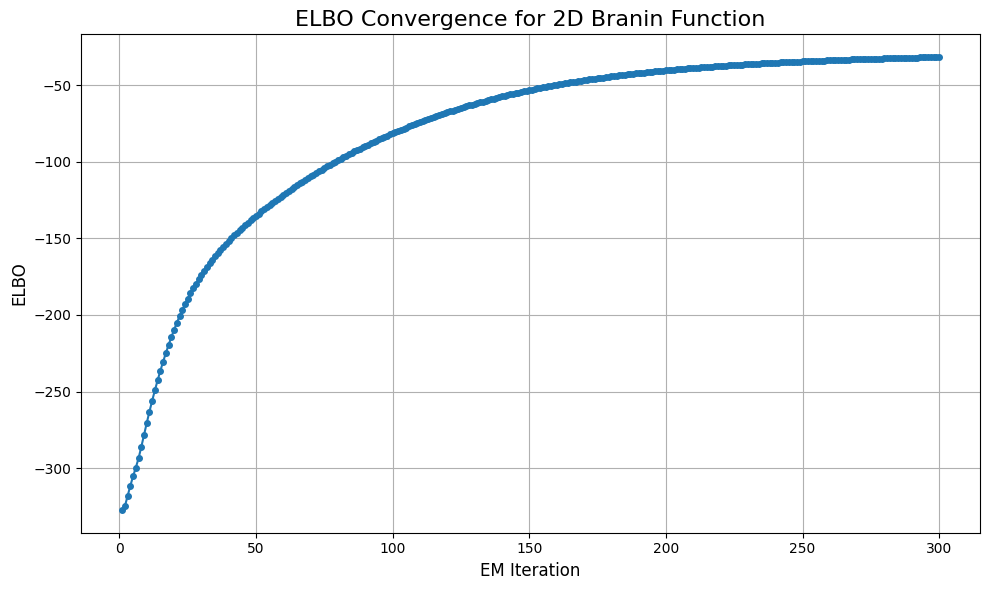

In [14]:
import torch
import torch.optim as optim
import math

def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    # Ensure lengthscale and variance are tensors for autograd
    lengthscale = torch.as_tensor(lengthscale, dtype=X1.dtype, device=X1.device)
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    
    sqdist = torch.cdist(X1, X2, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / lengthscale**2)

class SparseTPRTFullBatch:
    """
    Implementation of Variational EM for Student-t Process Regression.
    - E-Step: CAVI updates for variational parameters.
    - M-Step: Gradient-based optimization of model hyperparameters and inducing points.
    """
    def __init__(self, X, y, M, nu_f=5.0, nu_e=5.0, kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=1.0):
        """
        Args:
            X (torch.Tensor): Training inputs, shape (N, D).
            y (torch.Tensor): Training outputs, shape (N, 1) or (N,).
            M (int): Number of inducing points.
            ... (hyperparameters)
        """
        self.X = X
        self.y = y.squeeze()
        self.N, self.D = X.shape
        self.M = M

        # --- Initialize Inducing Points using Sobol sequence ---
        Z_initial = self._initialize_inducing_points()
        self.Z = torch.nn.Parameter(Z_initial)

        # --- Initialize Hyperparameters (M-step) ---
        # These are now learnable parameters. We optimize their log for stability.
        self.log_nu_f = torch.nn.Parameter(torch.log(torch.tensor(nu_f, dtype=X.dtype)))
        self.log_nu_epsilon = torch.nn.Parameter(torch.log(torch.tensor(nu_e, dtype=X.dtype)))
        self.log_sigma_sq = torch.nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2, dtype=X.dtype)))
        self.log_kernel_lengthscale = torch.nn.Parameter(torch.log(torch.tensor(kernel_lengthscale, dtype=X.dtype)))
        self.log_kernel_variance = torch.nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=X.dtype)))

        # --- Initialize Variational Parameters (E-step) ---
        # Ensure all parameters are on the same device and have the same dtype as the data
        self.m_u = torch.zeros(self.M, 1, dtype=X.dtype, device=X.device)
        self.S_u = torch.eye(self.M, dtype=X.dtype, device=X.device)
        self.alpha_r = torch.tensor(1.0, dtype=X.dtype, device=X.device)
        self.beta_r = torch.tensor(1.0, dtype=X.dtype, device=X.device)
        self.alpha_lambda = torch.ones(self.N, dtype=X.dtype, device=X.device)
        self.beta_lambda = torch.ones(self.N, dtype=X.dtype, device=X.device)

    def _initialize_inducing_points(self):
        """
        Initializes inducing points using a Sobol sequence scaled to the data's bounds.
        This provides a more uniform coverage of the input space than random sampling.
        """
        # Determine the bounds of the input data
        min_bounds = self.X.min(dim=0).values
        max_bounds = self.X.max(dim=0).values

        # Create a Sobol engine
        sobol_engine = torch.quasirandom.SobolEngine(dimension=self.D, scramble=True, seed=0)
        
        # Generate points in the unit hypercube [0, 1]^D
        # Ensure dtype matches input data for consistency
        sobol_points_unit = sobol_engine.draw(self.M).to(self.X.dtype)
        
        # Scale the points to the data's bounds
        scaled_points = min_bounds + sobol_points_unit * (max_bounds - min_bounds)
        
        return scaled_points
    
    def _get_hyperparams(self):
        """Returns the exponentiated (positive) hyperparameters."""
        return {
            "nu_f": torch.exp(self.log_nu_f),
            "nu_epsilon": torch.exp(self.log_nu_epsilon),
            "sigma_sq": torch.exp(self.log_sigma_sq),
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance)
        }
        
    # def _e_step_deprecated(self, cavi_max_iter=1):
    #     """Performs the CAVI updates for the variational parameters (E-Step)."""
    #     with torch.no_grad(): # No gradients needed for the E-step updates
    #         params = self._get_hyperparams()
    #         K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M) * 1e-6
    #         K_ZZ_inv = torch.inverse(K_ZZ)
    #         K_XZ = rbf_kernel(self.X, self.Z, params['lengthscale'], params['variance'])
            
    #         for _ in range(cavi_max_iter):
    #             # Update q(lambda)
    #             K_ZZ_inv_m_u = torch.linalg.solve(K_ZZ, self.m_u)
    #             expected_f_mean = K_XZ @ K_ZZ_inv_m_u
    #             if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
    #             else: expected_r_inv = self.beta_r
    #             k_ii = torch.diag(rbf_kernel(self.X, self.X, params['lengthscale'], params['variance']))
    #             K_XZ_K_ZZ_inv = K_XZ @ K_ZZ_inv
    #             var_f_term1 = expected_r_inv * (k_ii - (K_XZ_K_ZZ_inv * K_XZ).sum(dim=1))
    #             var_f_term2 = (K_XZ_K_ZZ_inv @ self.S_u * K_XZ_K_ZZ_inv).sum(dim=1)
    #             var_f = var_f_term1 + var_f_term2
    #             expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f
    #             self.alpha_lambda = params['nu_epsilon'] / 2.0 + 0.5
    #             self.beta_lambda = params['nu_epsilon'] / 2.0 + (0.5 / params['sigma_sq']) * expected_sq_error

    #             # Update q(r)
    #             trace_term = torch.trace(K_ZZ_inv @ self.S_u)
    #             mean_term = self.m_u.T @ K_ZZ_inv @ self.m_u
    #             expected_u_quadratic_form = trace_term + mean_term
    #             self.alpha_r = params['nu_f'] / 2.0 + self.M / 2.0
    #             self.beta_r = params['nu_f'] / 2.0 + 0.5 * expected_u_quadratic_form.squeeze()

    #             # Update q(u)
    #             expected_r = self.alpha_r / self.beta_r
    #             expected_lambda = self.alpha_lambda / self.beta_lambda
    #             precision_u_prior = expected_r * K_ZZ_inv
    #             K_ZX = K_XZ.T
    #             A = K_ZX * (expected_lambda / params['sigma_sq'])
    #             B = A @ K_XZ
    #             precision_u_lik = K_ZZ_inv.T @ B @ K_ZZ_inv
    #             precision_u = precision_u_prior + precision_u_lik
    #             self.S_u = torch.inverse(precision_u + torch.eye(self.M) * 1e-6)
    #             b = K_ZZ_inv.T @ (K_ZX @ (expected_lambda * self.y / params['sigma_sq']))
    #             self.m_u = (self.S_u @ b).unsqueeze(1)
    
    def _update_q_lambda(self, params, L_ZZ, K_XZ, K_ZX, k_ii):
        # K_ZZ_inv @ m_u 
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        expected_f_mean = K_XZ @ KZZ_inv_m_u

        # E[r^{-1}]
        if self.alpha_r > 1:
            expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else:
            expected_r_inv = self.beta_r 

        # K_XZ @ K_ZZ_inv
        KXZ_KZZ_inv = torch.cholesky_solve(K_ZX, L_ZZ).T
        
        # diag(A @ B) = (A * B.T).sum(dim=1)
        var_f_term1 = expected_r_inv * (k_ii - (KXZ_KZZ_inv * K_XZ).sum(dim=1))
        # diag(KXZ_KZZ_inv @ S_u @ KXZ_KZZ_inv.T)
        var_f_term2 = (KXZ_KZZ_inv @ self.S_u * KXZ_KZZ_inv).sum(dim=1)
        var_f = var_f_term1 + var_f_term2

        expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f
        self.alpha_lambda = params['nu_epsilon'] / 2.0 + 0.5
        self.beta_lambda = params['nu_epsilon'] / 2.0 + (0.5 / params['sigma_sq']) * expected_sq_error

    def _update_q_r(self, params, L_ZZ):
        # E[u^T K_ZZ^{-1} u]
        trace_term = torch.trace(torch.cholesky_solve(self.S_u, L_ZZ))
        # K_ZZ_inv @ m_u
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        mean_term = self.m_u.T @ KZZ_inv_m_u
        expected_u_quadratic_form = trace_term + mean_term

        self.alpha_r = params['nu_f'] / 2.0 + self.M / 2.0
        self.beta_r = params['nu_f'] / 2.0 + 0.5 * expected_u_quadratic_form.squeeze()

    def _update_q_u(self, params, K_ZZ, K_XZ, K_ZX):
        expected_r = self.alpha_r / self.beta_r
        expected_lambda = self.alpha_lambda / self.beta_lambda
        c = expected_lambda.squeeze() / params['sigma_sq']

        # Woodbury's formula
        # B = K_ZX @ diag(c) @ K_XZ 
        B = (K_ZX * c) @ K_XZ 

        # (E[r]*K_ZZ + B)
        precision_inner = expected_r * K_ZZ + B
        L_precision_inner = torch.linalg.cholesky(precision_inner)
        
        # S_u = K_ZZ @ (E[r]*K_ZZ + B)^-1 @ K_ZZ
        tmp_S = torch.cholesky_solve(K_ZZ, L_precision_inner)
        self.S_u = K_ZZ @ tmp_S

        # m_u = S_u @ K_ZZ^-1 @ b_lik = K_ZZ @ (E[r]*K_ZZ + B)^-1 @ b_lik
        # b_lik = K_ZX @ (c*y)
        y_term = K_ZX @ (self.y.squeeze() * c)
        m_u_unscaled = torch.cholesky_solve(y_term.unsqueeze(1), L_precision_inner)
        self.m_u = K_ZZ @ m_u_unscaled

    def _cavi_step(self, params, K_ZZ, L_ZZ, K_XZ, K_ZX, k_ii):
        self._update_q_lambda(params, L_ZZ, K_XZ, K_ZX, k_ii)
        self._update_q_r(params, L_ZZ)
        self._update_q_u(params, K_ZZ, K_XZ, K_ZX)

    def _e_step(self, cavi_max_iter=20):
        with torch.no_grad(): 
            params = self._get_hyperparams()
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
            L_ZZ = torch.linalg.cholesky(K_ZZ)
            K_XZ = rbf_kernel(self.X, self.Z, params['lengthscale'], params['variance'])
            K_ZX = K_XZ.T
            # k_ii = torch.full((self.X.shape[0],), params['variance'], device=self.X.device)
            k_ii = params['variance'].expand(self.X.shape[0])

            for _ in range(cavi_max_iter):
                self._cavi_step(params, K_ZZ, L_ZZ, K_XZ, K_ZX, k_ii)

    def _m_step(self, optimizer):
        """Performs the gradient update for the hyperparameters (M-Step)."""
        optimizer.zero_grad()
        elbo = self._calculate_elbo()
        loss = -elbo # Maximize ELBO by minimizing -ELBO
        loss.backward()
        optimizer.step()
        return elbo.item()

    def fit(self, max_iter_global=100, cavi_max_iter=10, lr=0.01):
        """Runs the full Variational EM algorithm."""
        optimizer = optim.Adam(
            [self.log_nu_f, self.log_nu_epsilon, self.log_sigma_sq,
             self.log_kernel_lengthscale, self.log_kernel_variance, self.Z],
            lr=lr
        )
        
        elbo_history = []
        print("Starting Variational EM optimization...")
        for i in range(max_iter_global):
            self._e_step(cavi_max_iter=cavi_max_iter)
            elbo = self._m_step(optimizer)
            elbo_history.append(elbo)
            
            if (i + 1) % 50 == 0:
                print(f"EM Iteration {i+1}/{max_iter_global}, ELBO: {elbo:.4f}")
        
        print("\nOptimization finished.")
        return elbo_history

    # def _calculate_elbo_deprecated(self):
    #     """Calculates the Evidence Lower Bound (ELBO) for the M-step."""
    #     params = self._get_hyperparams()
        
    #     K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M) * 1e-6
    #     K_ZZ_inv = torch.inverse(K_ZZ)
    #     K_XZ = rbf_kernel(self.X, self.Z, params['lengthscale'], params['variance'])
    #     k_ii = torch.diag(rbf_kernel(self.X, self.X, params['lengthscale'], params['variance']))

    #     # 1. Expected Log-Likelihood
    #     expected_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)
    #     expected_lambda = self.alpha_lambda / self.beta_lambda
    #     K_ZZ_inv_m_u = torch.linalg.solve(K_ZZ, self.m_u)
    #     expected_f_mean = K_XZ @ K_ZZ_inv_m_u
    #     if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
    #     else: expected_r_inv = self.beta_r
    #     K_XZ_K_ZZ_inv = K_XZ @ K_ZZ_inv
    #     var_f = expected_r_inv * (k_ii - (K_XZ_K_ZZ_inv * K_XZ).sum(dim=1)) + \
    #             (K_XZ_K_ZZ_inv @ self.S_u * K_XZ_K_ZZ_inv).sum(dim=1)
    #     expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f
        
    #     log_lik = 0.5 * torch.sum(expected_log_lambda - math.log(2 * math.pi) - torch.log(params['sigma_sq']) - \
    #                               expected_lambda / params['sigma_sq'] * expected_sq_error)

    #     # 2. KL Divergences
    #     p_alpha_r, p_beta_r = params['nu_f'] / 2.0, params['nu_f'] / 2.0
    #     kl_r = (self.alpha_r - p_alpha_r) * torch.digamma(self.alpha_r) - torch.lgamma(self.alpha_r) + torch.lgamma(p_alpha_r) + \
    #            p_alpha_r * (torch.log(self.beta_r) - torch.log(p_beta_r)) + self.alpha_r * (p_beta_r - self.beta_r) / self.beta_r
        
    #     expected_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
    #     kl_u = 0.5 * (
    #         -torch.logdet(self.S_u) - self.M * expected_log_r + torch.logdet(K_ZZ) + \
    #         (self.alpha_r / self.beta_r) * (torch.trace(K_ZZ_inv @ self.S_u) + self.m_u.T @ K_ZZ_inv @ self.m_u) - self.M
    #     ).squeeze()
        
    #     # CORRECTED a typo here: params['nu_e'] -> params['nu_epsilon']
    #     p_alpha_lambda, p_beta_lambda = params['nu_epsilon'] / 2.0, params['nu_epsilon'] / 2.0
    #     kl_lambda = torch.sum((self.alpha_lambda - p_alpha_lambda) * torch.digamma(self.alpha_lambda) - \
    #                 torch.lgamma(self.alpha_lambda) + torch.lgamma(p_alpha_lambda) + \
    #                 p_alpha_lambda * (torch.log(self.beta_lambda) - torch.log(p_beta_lambda)) + \
    #                 self.alpha_lambda * (p_beta_lambda - self.beta_lambda) / self.beta_lambda)

    #     return log_lik - kl_u - kl_r - kl_lambda

    def _calculate_elbo(self):
        params = self._get_hyperparams()
        K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
        L_ZZ = torch.linalg.cholesky(K_ZZ)
        K_XZ = rbf_kernel(self.X, self.Z, params['lengthscale'], params['variance'])
        K_ZX = K_XZ.T
        k_ii = params['variance'].expand(self.X.shape[0])
        
        # cholesky decomposition of S_u 
        L_S = torch.linalg.cholesky(self.S_u)

        # K_ZZ_inv @ m_u
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        # K_XZ @ K_ZZ_inv
        KXZ_KZZ_inv = torch.cholesky_solve(K_ZX, L_ZZ).T

        # --- 1. Expected Log-Likelihood ---w
        expected_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)
        expected_lambda = self.alpha_lambda / self.beta_lambda
        
        expected_f_mean = K_XZ @ KZZ_inv_m_u
        
        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r
        
        var_f_term1 = expected_r_inv * (k_ii - (KXZ_KZZ_inv * K_XZ).sum(dim=1))
        var_f_term2 = (KXZ_KZZ_inv @ self.S_u * KXZ_KZZ_inv).sum(dim=1)
        var_f = var_f_term1 + var_f_term2
        
        expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f
        
        log_lik = 0.5 * torch.sum(expected_log_lambda - math.log(2 * math.pi) - torch.log(params['sigma_sq']) - \
                                  (expected_lambda / params['sigma_sq']) * expected_sq_error)

        # --- 2. KL Divergences ---
        
        # KL[q(r) || p(r)]
        p_alpha_r, p_beta_r = params['nu_f'] / 2.0, params['nu_f'] / 2.0
        kl_r = (self.alpha_r - p_alpha_r) * torch.digamma(self.alpha_r) - torch.lgamma(self.alpha_r) + torch.lgamma(p_alpha_r) + \
               p_alpha_r * (torch.log(self.beta_r) - torch.log(p_beta_r)) + self.alpha_r * (p_beta_r - self.beta_r) / self.beta_r
        
        # KL[q(u) || p(u)]
        expected_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        expected_r = self.alpha_r / self.beta_r
        
        # logdet(S_u), logdet(K_ZZ) 
        logdet_S_u = 2 * torch.sum(torch.log(torch.diag(L_S)))
        logdet_K_ZZ = 2 * torch.sum(torch.log(torch.diag(L_ZZ)))
        
        # trace(K_ZZ_inv @ S_u)
        trace_KZZinv_Su = torch.trace(torch.cholesky_solve(self.S_u, L_ZZ))
        # m_u^T @ K_ZZ_inv @ m_u
        m_T_KZZinv_m = self.m_u.T @ KZZ_inv_m_u 
        
        # E[u^T K_ZZ^{-1} u] = trace(K_ZZ^{-1} S_u) + m_u^T K_ZZ^{-1} m_u
        expected_u_quadratic = trace_KZZinv_Su + m_T_KZZinv_m
        
        kl_u = 0.5 * (
            -logdet_S_u - self.M * expected_log_r + logdet_K_ZZ + \
            expected_r * expected_u_quadratic - self.M
        ).squeeze()
        
        # KL[q(lambda) || p(lambda)]
        p_alpha_lambda, p_beta_lambda = params['nu_epsilon'] / 2.0, params['nu_epsilon'] / 2.0
        kl_lambda = torch.sum((self.alpha_lambda - p_alpha_lambda) * torch.digamma(self.alpha_lambda) - \
                    torch.lgamma(self.alpha_lambda) + torch.lgamma(p_alpha_lambda) + \
                    p_alpha_lambda * (torch.log(self.beta_lambda) - torch.log(p_beta_lambda)) + \
                    self.alpha_lambda * (p_beta_lambda - self.beta_lambda) / self.beta_lambda)

        return log_lik - kl_u - kl_r - kl_lambda

    def predict(self, X_test):
        """
        Makes predictions for new data X_test.
        Returns the parameters of the predictive Student-t distribution.
        """
        with torch.no_grad():
            params = self._get_hyperparams()
            
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M) * 1e-6
            K_ZZ_inv = torch.inverse(K_ZZ)
            K_star_Z = rbf_kernel(X_test, self.Z, params['lengthscale'], params['variance'])
            k_star_star = torch.diag(rbf_kernel(X_test, X_test, params['lengthscale'], params['variance']))

            K_ZZ_inv_m_u = torch.linalg.solve(K_ZZ, self.m_u)
            pred_mean = (K_star_Z @ K_ZZ_inv_m_u).squeeze()

            K_star_Z_K_ZZ_inv = K_star_Z @ K_ZZ_inv
            gp_var = k_star_star - (K_star_Z_K_ZZ_inv * K_star_Z).sum(dim=1) + \
                     (K_star_Z_K_ZZ_inv @ self.S_u * K_star_Z_K_ZZ_inv).sum(dim=1)
            
            pred_nu = 2 * self.alpha_r
            pred_scale_sq = gp_var * (self.beta_r / self.alpha_r)
            
            return pred_mean, pred_scale_sq, pred_nu

            


if __name__ == '__main__':
    import matplotlib.pyplot as plt
    import math

    # --- グローバル設定 ---
    # デフォルトのデータ型をfloat64に設定し、精度を向上
    torch.set_default_dtype(torch.float64)
    # 乱数シードを固定して再現性を確保
    torch.manual_seed(42)

    # --- 1. 2次元テスト関数のデータ生成 ---
    
    # Branin関数の定義（少しスケールを調整）
    def branin_func(X):
        x1 = X[:, 0]
        x2 = X[:, 1]
        a = 1.
        b = 5.1 / (4. * math.pi**2)
        c = 5. / math.pi
        r = 6.
        s = 10.
        t = 1. / (8. * math.pi)
        ret = a * (x2 - b * x1**2 + c * x1 - r)**2 + s * (1 - t) * torch.cos(x1) + s
        # 出力を-1から1程度の範囲に正規化
        return (ret - 50) / 50

    # データ点の数
    N_approx = 200 # おおよそのデータ点数
    # 2次元の入力データをグリッドで生成
    grid_side = torch.linspace(-5, 10, int(math.sqrt(N_approx)))
    grid_x, grid_y = torch.meshgrid(grid_side, grid_side, indexing='ij')
    X_train = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1)
    N = X_train.shape[0] # グリッド数に合わせてNを更新

    # 真の値とノイズの追加
    y_true = branin_func(X_train).unsqueeze(1)
    noise = torch.randn(N, 1) * 0.1
    
    # 外れ値（Student-t分布からサンプリング）
    t_dist = torch.distributions.StudentT(df=3.0)
    outlier_noise = t_dist.sample((N, 1)) * 0.5
    
    y_train = y_true + noise
    
    # 10%のデータ点に外れ値を追加
    num_outliers = int(N * 0.1)
    outlier_indices = torch.randperm(N)[:num_outliers]
    y_train[outlier_indices] += outlier_noise[outlier_indices]

    # --- 2. モデルのセットアップ ---
    
    # 誘導点の数を指定
    M = 40
    
    # モデルのインスタンス化 (Z_initial の代わりに M を渡す)
    model = SparseTPRTFullBatch(
        X=X_train,
        y=y_train,
        M=M, # <- ここが変更点
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=2.0,
        kernel_variance=1.0,
        likelihood_sigma=0.3
    )

    # --- 3. モデルの学習とELBOの記録 ---
    elbo_history = model.fit(max_iter_global=300, cavi_max_iter=5, lr=0.01)

    # --- 4. 学習後のハイパーパラメータと誘導点の表示（任意） ---
    final_params = model._get_hyperparams()
    print("\n--- Optimized Hyperparameters ---")
    for key, value in final_params.items():
        print(f"{key}: {value.item():.4f}")
    
    # 最適化された誘導点の最初の5点を表示
    print(f"\n--- Optimized Z (first 5) ---\n{model.Z.detach()[:5].numpy()}")
    print("---------------------------------")


    # --- 5. ELBOの履歴をプロット ---
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(elbo_history) + 1), elbo_history, marker='o', linestyle='-', markersize=4)
    plt.title('ELBO Convergence for 2D Branin Function', fontsize=16)
    plt.xlabel('EM Iteration', fontsize=12)
    plt.ylabel('ELBO', fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Starting Variational EM optimization...
EM Iteration 50/100, ELBO: -66.6918
EM Iteration 100/100, ELBO: 129.0571

Optimization finished.


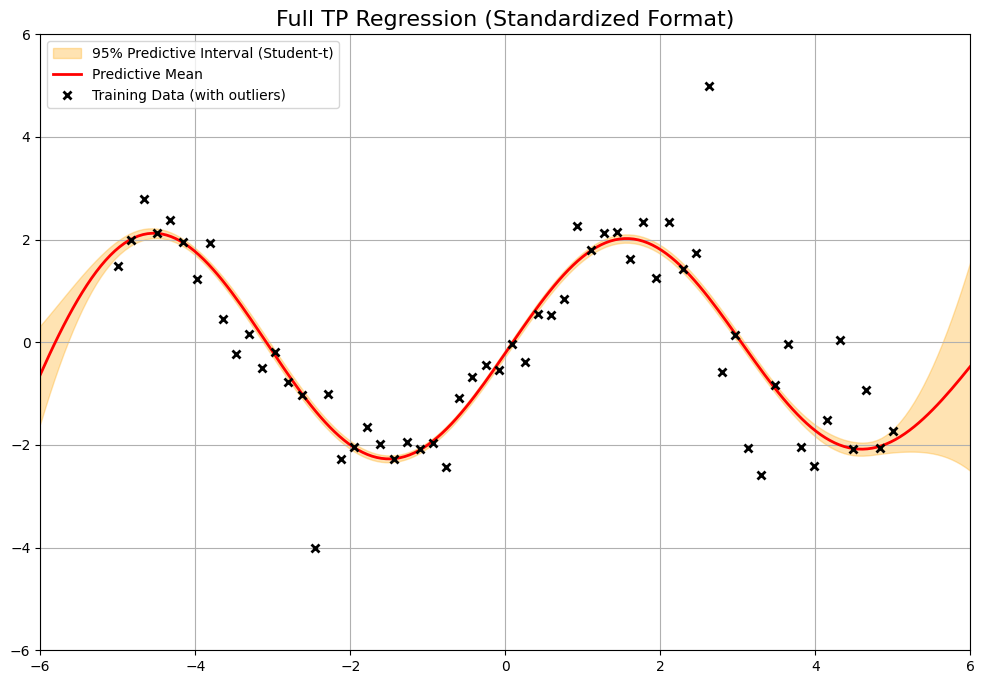

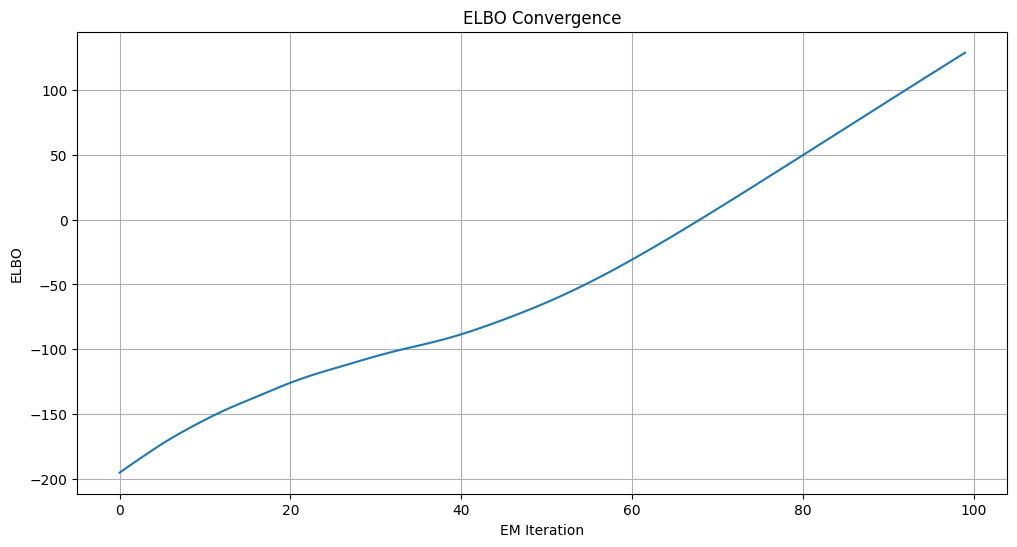

In [ ]:
import torch
import torch.nn as nn
import math


def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    # Ensure lengthscale and variance are tensors for autograd
    lengthscale = torch.as_tensor(lengthscale, dtype=X1.dtype, device=X1.device)
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    
    sqdist = torch.cdist(X1, X2, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / lengthscale**2)

class TPRTFullBatch:
    """
    Implementation of the full (non-sparse) Student-t Process regression model.
    This version is aligned with the structure of the SparseTPRTFullBatch class.
    """
    def __init__(self, X, y, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        
        self.X = X
        self.y = y.view(-1, 1) # Ensure y is always of shape (N, 1)
        self.N, self.D = X.shape

        # --- Hyperparameters as nn.Parameter for optimization ---
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale, dtype=X.dtype)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=X.dtype)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2, dtype=X.dtype)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f, dtype=X.dtype)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e, dtype=X.dtype)))

        # --- Variational Parameters (updated via CAVI) ---
        self.m_f = torch.zeros(self.N, 1, dtype=X.dtype, device=X.device)
        self.L_f = torch.eye(self.N, dtype=X.dtype, device=X.device)
        self.alpha_r = torch.tensor(1.0, dtype=X.dtype, device=X.device)
        self.beta_r = torch.tensor(1.0, dtype=X.dtype, device=X.device)
        self.alpha_lambda = torch.ones(self.N, 1, dtype=X.dtype, device=X.device)
        self.beta_lambda = torch.ones(self.N, 1, dtype=X.dtype, device=X.device)

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        return {
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance),
            "sigma_sq": torch.exp(self.log_likelihood_sigma_sq),
            "nu_f": torch.exp(self.log_nu_f),
            "nu_e": torch.exp(self.log_nu_e)
        }

    def _update_q_lambda(self, params):
        """CAVI update for q(lambda_i). Receives params as an argument."""
        # params = self._get_hyperparams() <- 削除
        S_f = self.L_f @ self.L_f.T
        var_f = S_f.diag().unsqueeze(1)
        expected_f_mean = self.m_f

        self.alpha_lambda = params['nu_e'] / 2.0 + 0.5
        expected_sq_error = (self.y - expected_f_mean).pow(2) + var_f
        self.beta_lambda = params['nu_e'] / 2.0 + (1.0 / (2.0 * params['sigma_sq'])) * expected_sq_error

    def _update_q_r(self, params, Lxx):
        """CAVI update for q(r). Receives params and Lxx as arguments."""
        # params = self._get_hyperparams() <- 削除
        S_f = self.L_f @ self.L_f.T
        
        trace_term = torch.trace(torch.cholesky_solve(S_f, Lxx))
        mean_term = self.m_f.T @ torch.cholesky_solve(self.m_f, Lxx)
        expected_f_quadratic_form = trace_term + mean_term

        self.alpha_r = params['nu_f'] / 2.0 + self.N / 2.0
        self.beta_r = params['nu_f'] / 2.0 + 0.5 * expected_f_quadratic_form.squeeze()

    def _update_q_f(self, params, Lxx):
        """CAVI update for q(f). Receives params and Lxx as arguments."""
        # params = self._get_hyperparams() <- 削除
        expected_r = self.alpha_r / self.beta_r
        expected_lambda = self.alpha_lambda / self.beta_lambda

        Kxx_inv = torch.cholesky_inverse(Lxx)
        S_f_inv = expected_r * Kxx_inv + torch.diag(expected_lambda.squeeze() / params['sigma_sq'])
        
        L_f_inv = torch.linalg.cholesky(S_f_inv)
        self.L_f = torch.triangular_solve(torch.eye(self.N, device=self.X.device), L_f_inv, upper=False)[0]

        temp_vec = (expected_lambda / params['sigma_sq']) * self.y
        self.m_f = torch.cholesky_solve(temp_vec, L_f_inv)

    def _cavi_step(self, params, Lxx):
        """
        Wrapper for a single CAVI update cycle.
        This follows the structure of the sparse model template.
        """
        self._update_q_lambda(params)
        self._update_q_r(params, Lxx)
        self._update_q_f(params, Lxx)
        
    def _e_step(self, cavi_max_iter=10):
        """
        Performs the E-Step by running CAVI updates.
        This method now computes its own kernel matrix based on the current hyperparameters.
        """
        with torch.no_grad():
            # 1. Get hyperparameters at the start of the E-step
            params = self._get_hyperparams()
            
            # 2. Compute common components for the CAVI loop
            Kxx = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
            Kxx += torch.eye(self.N, device=self.X.device) * 1e-6
            Lxx = torch.linalg.cholesky(Kxx)

            # 3. Run the CAVI update loop
            for _ in range(cavi_max_iter):
                self._cavi_step(params, Lxx)

    def _m_step(self, optimizer):
        """Performs the M-Step by updating hyperparameters."""
        optimizer.zero_grad()
        elbo = self._calculate_elbo()
        loss = -elbo
        loss.backward()
        optimizer.step()
        return elbo.item()

    def fit(self, max_iter_global=100, cavi_max_iter=10, lr=0.01):
        """Fits the model using the Variational EM algorithm."""
        optimizer = torch.optim.Adam([
            self.log_kernel_lengthscale, self.log_kernel_variance,
            self.log_likelihood_sigma_sq, self.log_nu_f, self.log_nu_e
        ], lr=lr)

        elbo_history = []
        print("Starting Variational EM optimization...")
        for i in range(max_iter_global):
            self._e_step(cavi_max_iter=cavi_max_iter)
            elbo = self._m_step(optimizer)
            elbo_history.append(elbo)
            
            if (i + 1) % 50 == 0:
                print(f"EM Iteration {i+1}/{max_iter_global}, ELBO: {elbo:.4f}")

        print("\nOptimization finished.")
        return elbo_history

    def _calculate_elbo(self):
        """
        Calculates the Evidence Lower Bound (ELBO).
        This version strictly maintains the original calculation logic.
        """
        params = self._get_hyperparams()
        Kxx = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
        Kxx += torch.eye(self.N, device=self.X.device) * 1e-6
        Lxx = torch.linalg.cholesky(Kxx)
        S_f = self.L_f @ self.L_f.T

        # --- 1. Expected Log Likelihood (E[log p(y|f, lambda)]) ---
        E_q_f = self.m_f
        Var_q_f = S_f.diag().unsqueeze(1)
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f

        E_lambda = self.alpha_lambda / self.beta_lambda
        E_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)

        e_log_lik = -0.5 * self.N * math.log(2 * math.pi) - 0.5 * self.N * torch.log(params['sigma_sq']) + \
                    0.5 * torch.sum(E_log_lambda) - \
                    0.5 / params['sigma_sq'] * torch.sum(E_lambda * expected_sq_error)

        # --- 2. KL Divergence for f and r (as in original code) ---
        # Note: This part calculates -(E[log p(f,r)] - E[log q(f,r)])
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)

        # E[log q(f)]
        # Original code simplifies this term, so we follow it.
        # It's related to the entropy of a Gaussian.
        log_q_f = -torch.sum(torch.log(torch.diag(self.L_f)))
        
        # E[log q(r)]
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        # E[log p(f|r)]
        trace_term = torch.trace(torch.cholesky_solve(S_f, Lxx))
        quad_form_term = self.m_f.T @ torch.cholesky_solve(self.m_f, Lxx)
        E_quad_form_f = trace_term + quad_form_term
        log_det_Kxx = 2 * torch.sum(torch.log(torch.diag(Lxx)))
        E_log_p_f_r = -0.5 * log_det_Kxx + 0.5 * self.N * E_log_r - 0.5 * E_r * E_quad_form_f

        # E[log p(r)]
        p_alpha_r, p_beta_r = params['nu_f'] / 2.0, params['nu_f'] / 2.0
        E_log_p_r = p_alpha_r * torch.log(p_beta_r) - torch.lgamma(p_alpha_r) + \
                    (p_alpha_r - 1) * E_log_r - p_beta_r * E_r

        # The constant -0.5 * N * log(2*pi) from log q(f) and E[log p(f|r)] cancel out.
        # Original grouping: log_q_f + log_q_r - E_log_p_f_r - E_log_p_r
        kl_f_r_grouped = (log_q_f + log_q_r) - (E_log_p_f_r + E_log_p_r)

        # --- 3. KL Divergence for lambda_i (as in original code) ---
        # Note: This part calculates - sum(E[log p(lambda_i)] - E[log q(lambda_i)])
        p_alpha_lambda, p_beta_lambda = params['nu_e'] / 2.0, params['nu_e'] / 2.0
        
        # Replicating the exact structure from the original snippet
        kl_lambda = torch.lgamma(self.alpha_lambda) - self.alpha_lambda * torch.log(self.beta_lambda) - \
                    (torch.lgamma(p_alpha_lambda) - p_alpha_lambda * torch.log(p_beta_lambda)) - \
                    (self.alpha_lambda - p_alpha_lambda) * E_log_lambda + \
                    (self.beta_lambda - p_beta_lambda) * E_lambda

        kl_lambda_sum = torch.sum(kl_lambda)

        # Combine terms exactly as in the original formulation
        elbo = e_log_lik - kl_f_r_grouped - kl_lambda_sum
        
        return elbo


    def predict(self, X_test):
        """Make predictions at new test points X_test."""
        with torch.no_grad():
            params = self._get_hyperparams()
            K_star_x = rbf_kernel(X_test, self.X, params['lengthscale'], params['variance'])
            K_star_star_diag = rbf_kernel(X_test, X_test, params['lengthscale'], params['variance']).diag()
            Kxx = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
            Kxx += torch.eye(self.N, device=self.X.device) * 1e-6
            Lxx = torch.linalg.cholesky(Kxx)

            Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
            pred_mean = K_star_x @ Kxx_inv_mf

            S_f = self.L_f @ self.L_f.T
            Kxx_inv_k_x_star = torch.cholesky_solve(K_star_x.T, Lxx)
            
            var_from_q_f = (K_star_x @ torch.cholesky_solve(S_f @ Kxx_inv_k_x_star, Lxx)).diag()
            
            E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
            var_from_prior = E_inv_r * (K_star_star_diag - (K_star_x * Kxx_inv_k_x_star.T).sum(dim=1))

            pred_var = var_from_prior + var_from_q_f
            pred_nu = 2 * self.alpha_r

            return pred_mean, pred_var.unsqueeze(1), pred_nu
        

if __name__ == '__main__':

    import matplotlib.pyplot as plt
    from scipy.stats import t
    torch.set_default_dtype(torch.float64)

    # 1. Generate data
    N = 60
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.5
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.3
    y_train = y_true + noise
    
    # Add some significant outliers
    outlier_indices = torch.randperm(N)[:8]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[15] = -4.0
    y_train[45] = 5.0

    # 2. Setup the non-sparse model
    model = TPRTFullBatch(
        X=X_train,
        y=y_train,
        nu_f=3.0,
        nu_e=3.0,
        kernel_lengthscale=1.0,
        kernel_variance=1.0,
        likelihood_sigma=1.0
    )

    # 3. Fit the model
    elbo_history = model.fit(max_iter_global=100, cavi_max_iter=15, lr=0.05)

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')

    plt.title('Full TP Regression (Standardized Format)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    plt.figure(figsize=(12, 6))
    plt.plot(elbo_history)
    plt.title("ELBO Convergence")
    plt.xlabel("EM Iteration")
    plt.ylabel("ELBO")
    plt.grid(True)
    
    plt.show()

Starting Variational EM optimization...
EM Iteration 50/300, ELBO: -98.5026
EM Iteration 100/300, ELBO: -75.3924
EM Iteration 150/300, ELBO: -57.8105
EM Iteration 200/300, ELBO: -46.7926
EM Iteration 250/300, ELBO: -40.2598
EM Iteration 300/300, ELBO: -36.5578

Optimization finished.

--- Initial Z ---
[-0.24892816  0.60123145  4.8778324  -4.60510616 -2.5409678   2.82091518
  2.32608818 -1.98106452 -1.7011305   1.35618074  3.16600534 -3.44602665
 -4.25286996  3.98021761  0.87397047 -1.22634768 -0.71421588  1.07238158
  4.09310551 -3.82626136]

--- Optimized Z ---
[-0.11402187  0.38551803  4.91033228 -4.88938455 -2.73432604  2.75800096
  2.16185028 -2.19050145 -1.71747198  1.54613418  3.3161723  -3.26475196
 -4.44811355  3.86789601  1.0324707  -1.18420759 -0.67480844  1.25705376
  4.45501156 -3.90914572]
-------------------


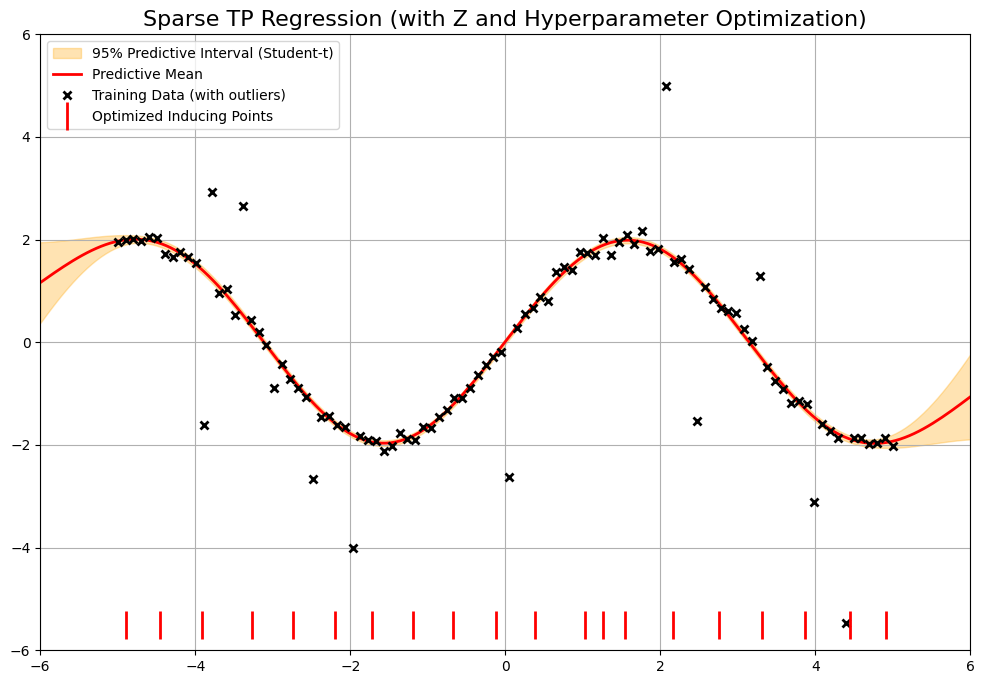

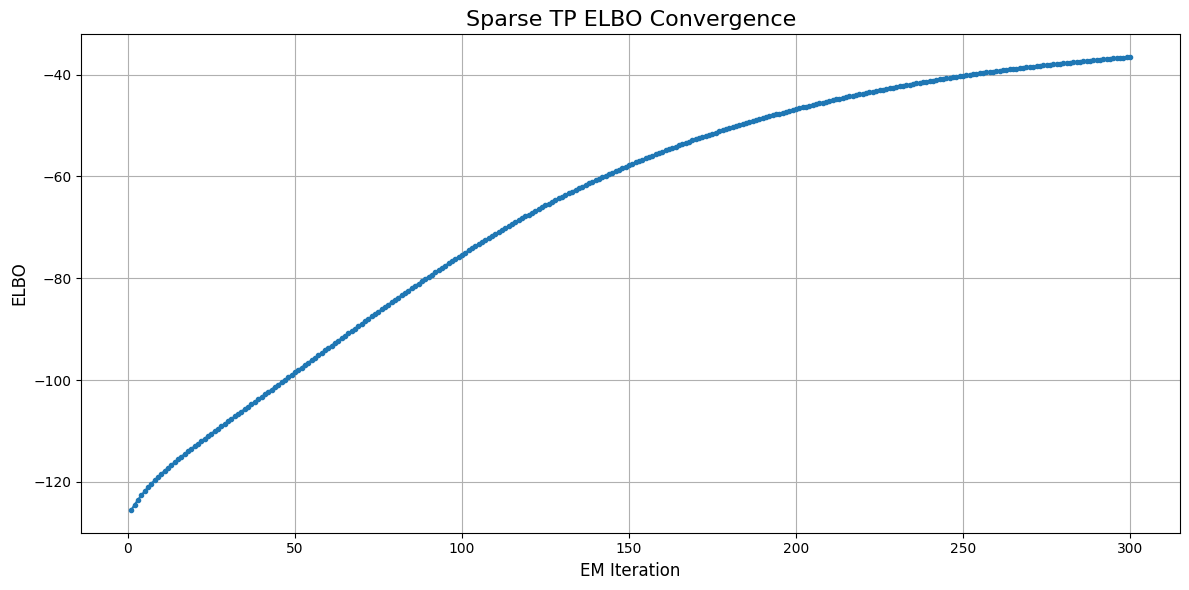

In [ ]:
import torch
import torch.nn as nn 
import torch.optim as optim
import math

def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    lengthscale = torch.as_tensor(lengthscale, dtype=X1.dtype, device=X1.device)
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    sqdist = torch.cdist(X1, X2, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / lengthscale**2)

class SparseTPRTFullBatch:
    """
    Implementation of Variational EM for Student-t Process Regression.
    - E-Step: CAVI updates for variational parameters.
    - M-Step: Gradient-based optimization of model hyperparameters and inducing points.
    """
    def __init__(self, X, y, M, nu_f=5.0, nu_e=5.0, kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=1.0):
        """
        Args:
            X (torch.Tensor): Training inputs, shape (N, D).
            y (torch.Tensor): Training outputs, shape (N, 1) or (N,).
            M (int): Number of inducing points.
            ... (hyperparameters)
        """
        self.X = X
        # ★★★ 修正点1: yの形状を(N, 1)に統一 ★★★
        self.y = y.view(-1, 1)
        self.N, self.D = X.shape
        self.M = M

        # --- Initialize Inducing Points using Sobol sequence ---
        Z_initial = self._initialize_inducing_points()
        self.Z = nn.Parameter(Z_initial)

        # --- Initialize Hyperparameters (M-step) ---
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f, dtype=X.dtype)))
        self.log_nu_epsilon = nn.Parameter(torch.log(torch.tensor(nu_e, dtype=X.dtype)))
        self.log_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2, dtype=X.dtype)))
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale, dtype=X.dtype)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=X.dtype)))

        # --- Initialize Variational Parameters (E-step) ---
        self.m_u = torch.zeros(self.M, 1, dtype=X.dtype, device=X.device)
        self.S_u = torch.eye(self.M, dtype=X.dtype, device=X.device)
        self.alpha_r = torch.tensor(1.0, dtype=X.dtype, device=X.device)
        self.beta_r = torch.tensor(1.0, dtype=X.dtype, device=X.device)
        # ★★★ 修正点2: alpha/beta_lambdaの形状を(N, 1)に統一 ★★★
        self.alpha_lambda = torch.ones(self.N, 1, dtype=X.dtype, device=X.device)
        self.beta_lambda = torch.ones(self.N, 1, dtype=X.dtype, device=X.device)

    def _initialize_inducing_points(self):
        """
        Initializes inducing points using a Sobol sequence scaled to the data's bounds.
        """
        min_bounds = self.X.min(dim=0).values
        max_bounds = self.X.max(dim=0).values
        sobol_engine = torch.quasirandom.SobolEngine(dimension=self.D, scramble=True, seed=0)
        sobol_points_unit = sobol_engine.draw(self.M).to(self.X.dtype)
        return min_bounds + sobol_points_unit * (max_bounds - min_bounds)
    
    def _get_hyperparams(self):
        """Returns the exponentiated (positive) hyperparameters."""
        return {
            "nu_f": torch.exp(self.log_nu_f),
            "nu_epsilon": torch.exp(self.log_nu_epsilon),
            "sigma_sq": torch.exp(self.log_sigma_sq),
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance)
        }
        
    def _update_q_lambda(self, params, L_ZZ, K_XZ, K_ZX, k_ii):
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        expected_f_mean = K_XZ @ KZZ_inv_m_u # Shape: (N, 1)

        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r 

        KXZ_KZZ_inv = torch.cholesky_solve(K_ZX, L_ZZ).T
        
        var_f_term1 = expected_r_inv * (k_ii - (KXZ_KZZ_inv * K_XZ).sum(dim=1))
        var_f_term2 = (KXZ_KZZ_inv @ self.S_u * KXZ_KZZ_inv).sum(dim=1)
        # ★★★ 修正点3: var_fの形状を(N, 1)に調整 ★★★
        var_f = (var_f_term1 + var_f_term2).unsqueeze(1)

        # y と expected_f_mean が (N, 1) なので .squeeze() は不要
        expected_sq_error = (self.y - expected_f_mean).pow(2) + var_f
        self.alpha_lambda = params['nu_epsilon'] / 2.0 + 0.5
        self.beta_lambda = params['nu_epsilon'] / 2.0 + (0.5 / params['sigma_sq']) * expected_sq_error

    def _update_q_r(self, params, L_ZZ):
        trace_term = torch.trace(torch.cholesky_solve(self.S_u, L_ZZ))
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        mean_term = self.m_u.T @ KZZ_inv_m_u
        expected_u_quadratic_form = trace_term + mean_term
        self.alpha_r = params['nu_f'] / 2.0 + self.M / 2.0
        self.beta_r = params['nu_f'] / 2.0 + 0.5 * expected_u_quadratic_form.squeeze()

    def _update_q_u(self, params, K_ZZ, K_XZ, K_ZX):
        expected_r = self.alpha_r / self.beta_r
        # alpha/beta_lambdaは(N, 1)なのでsqueeze()が必要
        expected_lambda = self.alpha_lambda.squeeze() / self.beta_lambda.squeeze()
        c = expected_lambda / params['sigma_sq']

        B = (K_ZX * c) @ K_XZ 
        precision_inner = expected_r * K_ZZ + B
        L_precision_inner = torch.linalg.cholesky(precision_inner)
        
        tmp_S = torch.cholesky_solve(K_ZZ, L_precision_inner)
        self.S_u = K_ZZ @ tmp_S

        # yは(N, 1)なのでsqueeze()が必要
        y_term = K_ZX @ (self.y.squeeze() * c)
        m_u_unscaled = torch.cholesky_solve(y_term.unsqueeze(1), L_precision_inner)
        self.m_u = K_ZZ @ m_u_unscaled

    def _cavi_step(self, params, K_ZZ, L_ZZ, K_XZ, K_ZX, k_ii):
        self._update_q_lambda(params, L_ZZ, K_XZ, K_ZX, k_ii)
        self._update_q_r(params, L_ZZ)
        self._update_q_u(params, K_ZZ, K_XZ, K_ZX)

    def _e_step(self, cavi_max_iter=20):
        with torch.no_grad(): 
            params = self._get_hyperparams()
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
            L_ZZ = torch.linalg.cholesky(K_ZZ)
            K_XZ = rbf_kernel(self.X, self.Z, params['lengthscale'], params['variance'])
            K_ZX = K_XZ.T
            k_ii = params['variance'].expand(self.X.shape[0])

            for _ in range(cavi_max_iter):
                self._cavi_step(params, K_ZZ, L_ZZ, K_XZ, K_ZX, k_ii)

    def _m_step(self, optimizer):
        """Performs the gradient update for the hyperparameters (M-Step)."""
        optimizer.zero_grad()
        elbo = self._calculate_elbo()
        loss = -elbo
        loss.backward()
        optimizer.step()
        return elbo.item()

    def fit(self, max_iter_global=100, cavi_max_iter=10, lr=0.01):
        """Runs the full Variational EM algorithm."""
        parameters_to_optimize = [
            self.log_nu_f, self.log_nu_epsilon, self.log_sigma_sq,
            self.log_kernel_lengthscale, self.log_kernel_variance, self.Z
        ]
        optimizer = optim.Adam(parameters_to_optimize, lr=lr)
        
        elbo_history = []
        print("Starting Variational EM optimization...")
        for i in range(max_iter_global):
            self._e_step(cavi_max_iter=cavi_max_iter)
            elbo = self._m_step(optimizer)
            elbo_history.append(elbo)
            
            if (i + 1) % 50 == 0:
                print(f"EM Iteration {i+1}/{max_iter_global}, ELBO: {elbo:.4f}")
        
        print("\nOptimization finished.")
        return elbo_history

    def _calculate_elbo(self):
        params = self._get_hyperparams()
        K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
        L_ZZ = torch.linalg.cholesky(K_ZZ)
        K_XZ = rbf_kernel(self.X, self.Z, params['lengthscale'], params['variance'])
        K_ZX = K_XZ.T
        k_ii = params['variance'].expand(self.X.shape[0])
        
        L_S = torch.linalg.cholesky(self.S_u)

        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        KXZ_KZZ_inv = torch.cholesky_solve(K_ZX, L_ZZ).T

        # --- 1. Expected Log-Likelihood ---
        expected_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)
        expected_lambda = self.alpha_lambda / self.beta_lambda
        
        expected_f_mean = K_XZ @ KZZ_inv_m_u # Shape: (N, 1)
        
        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r
        
        var_f_term1 = expected_r_inv * (k_ii - (KXZ_KZZ_inv * K_XZ).sum(dim=1))
        var_f_term2 = (KXZ_KZZ_inv @ self.S_u * KXZ_KZZ_inv).sum(dim=1)
        # ★★★ 修正点4: var_fの形状を(N, 1)に調整 ★★★
        var_f = (var_f_term1 + var_f_term2).unsqueeze(1)
        
        # yとexpected_f_meanは(N, 1)なのでsqueeze不要
        expected_sq_error = (self.y - expected_f_mean).pow(2) + var_f
        
        log_lik = 0.5 * torch.sum(expected_log_lambda - math.log(2 * math.pi) - torch.log(params['sigma_sq']) - \
                                  (expected_lambda / params['sigma_sq']) * expected_sq_error)

        # --- 2. KL Divergences ---
        p_alpha_r, p_beta_r = params['nu_f'] / 2.0, params['nu_f'] / 2.0
        kl_r = (self.alpha_r - p_alpha_r) * torch.digamma(self.alpha_r) - torch.lgamma(self.alpha_r) + torch.lgamma(p_alpha_r) + \
               p_alpha_r * (torch.log(self.beta_r) - torch.log(p_beta_r)) + self.alpha_r * (p_beta_r - self.beta_r) / self.beta_r
        
        expected_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        expected_r = self.alpha_r / self.beta_r
        
        logdet_S_u = 2 * torch.sum(torch.log(torch.diag(L_S)))
        logdet_K_ZZ = 2 * torch.sum(torch.log(torch.diag(L_ZZ)))
        
        trace_KZZinv_Su = torch.trace(torch.cholesky_solve(self.S_u, L_ZZ))
        m_T_KZZinv_m = self.m_u.T @ KZZ_inv_m_u 
        expected_u_quadratic = trace_KZZinv_Su + m_T_KZZinv_m
        
        kl_u = 0.5 * (
            -logdet_S_u - self.M * expected_log_r + logdet_K_ZZ + \
            expected_r * expected_u_quadratic - self.M
        ).squeeze()
        
        p_alpha_lambda, p_beta_lambda = params['nu_epsilon'] / 2.0, params['nu_epsilon'] / 2.0
        kl_lambda = torch.sum((self.alpha_lambda - p_alpha_lambda) * torch.digamma(self.alpha_lambda) - \
                    torch.lgamma(self.alpha_lambda) + torch.lgamma(p_alpha_lambda) + \
                    p_alpha_lambda * (torch.log(self.beta_lambda) - torch.log(p_beta_lambda)) + \
                    self.alpha_lambda * (p_beta_lambda - self.beta_lambda) / self.beta_lambda)

        return log_lik - kl_u - kl_r - kl_lambda

    def predict(self, X_test):
        """
        Makes predictions for new data X_test.
        """
        with torch.no_grad():
            params = self._get_hyperparams()
            
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
            L_ZZ = torch.linalg.cholesky(K_ZZ)
            K_star_Z = rbf_kernel(X_test, self.Z, params['lengthscale'], params['variance'])
            k_star_star = rbf_kernel(X_test, X_test, params['lengthscale'], params['variance']).diag()

            KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
            pred_mean = K_star_Z @ KZZ_inv_m_u

            K_star_Z_K_ZZ_inv = torch.cholesky_solve(K_star_Z.T, L_ZZ, upper=False).T
            
            gp_var = k_star_star - (K_star_Z_K_ZZ_inv * K_star_Z).sum(dim=1) + \
                     (K_star_Z_K_ZZ_inv @ self.S_u * K_star_Z_K_ZZ_inv).sum(dim=1)
            
            pred_nu = 2 * self.alpha_r
            pred_scale_sq = (gp_var * (self.beta_r / self.alpha_r)).unsqueeze(1)
            
            return pred_mean, pred_scale_sq, pred_nu
        



if __name__ == '__main__':

    import matplotlib.pyplot as plt
    from scipy.stats import t
    import math # 不要ですが、他のコードとの互換性のため残すこともあります

    # --- グローバル設定 ---
    torch.set_default_dtype(torch.float64)
    torch.manual_seed(42)

    # --- 1. 1次元データの生成 ---
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    # ノイズと外れ値の追加
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:10]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    # 手動でさらに強い外れ値を追加
    y_train[30] = -4.0
    y_train[70] = 5.0

    # --- 2. モデルのセットアップ ---
    
    # 誘導点の数を指定
    M = 20
    
    # モデルのインスタンス化 (Z_initial の代わりに M を渡す)
    model = SparseTPRTFullBatch(
        X=X_train,
        y=y_train,
        M=M, # <- ここが変更点
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 最適化前の初期誘導点を保存しておく
    initial_Z = model.Z.clone().detach()

    # --- 3. モデルの学習とELBOの記録 ---
    elbo_history = model.fit(max_iter_global=300, cavi_max_iter=5, lr=0.01)

    # --- 4. 誘導点の位置を表示 ---
    print("\n--- Initial Z ---")
    print(initial_Z.squeeze().numpy())
    print("\n--- Optimized Z ---")
    print(model.Z.detach().squeeze().numpy())
    print("-------------------")

    # --- 5. 予測の実行 ---
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # --- 6. 回帰結果の可視化 ---
    plt.figure(figsize=(12, 8))

    # 予測分布（Student-t）の95%信頼区間を計算
    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    # scipy.stats.tを使ってパーセント点関数(ppf)を計算
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, mew=2, label='Optimized Inducing Points')

    plt.title('Sparse TP Regression (with Z and Hyperparameter Optimization)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # --- 7. ELBOの履歴を可視化 ---
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(elbo_history) + 1), elbo_history, marker='.', linestyle='-')
    plt.title('Sparse TP ELBO Convergence', fontsize=16)
    plt.xlabel('EM Iteration', fontsize=12)
    plt.ylabel('ELBO', fontsize=12)
    plt.grid(True)
    plt.tight_layout()

    plt.show()